# Function 8

<b> Description of the Sample Application:</b> You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. 
Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.
For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this scor.




## Progress Log

| Week | Query Submitted (x1–x8) | Output (y) | Best y So Far | Acquisition / Strategy |
|---|---|---|---|---|
| Week 1 | 0.093998-0.081832-0.154891-0.104133-0.912141-0.345036-0.011181-0.477351 | 9.888207 | 9.888207 | GP (RBF, fixed hyperparameters) + UCB (β=2.0), candidate search over 10,000-point Latin Hypercube — exploration-heavy |
| Week 2 | 0.173855-0.145601-0.141754-0.086242-0.999999-0.457141-0.260715-0.999999 | 9.939383 | 9.939383 | GP (RBF, ARD, hyperparameters optimised) + UCB (β=1.5), next point via multi-start L-BFGS-B — shifting toward exploitation |
| Week 3 | 0.130530-0.145043-0.199622-0.056929-0.701352-0.471131-0.191028-0.000000 | 9.933047 | 9.939383 *(Week 3 slightly underperformed Week 2's incumbent)* | GP (RBF, ARD, hyperparameters optimised) + UCB (β=1.0), multi-start L-BFGS-B — further exploitation |
| Week 4 | 0.105972-0.149435-0.157841-0.220093-0.869536-0.490015-0.185910-0.999999 | **9.973776** | **9.973776** | GP (RBF, ARD, optimised) + UCB (β=0.7) - **new best**, exploitation paid off |
| Week 5 | 0.000000-0.034040-0.209666-0.153509-0.999999-0.551705-0.199997-0.999999 | 9.908828 | 9.973776 | **Change in Strategy:** β raised 0.7 → **3.0**, x8 frozen as a confirmed nuisance dimension, noise floor raised to 1e-4. Deliberate exploration probe |
| Week 6 | 0.120036-0.152437-0.165666-0.194783-0.914473-0.472016-0.192359-0.999999 | 9.969918 | 9.973776 | Back to exploitation, β=0.5 — returned 0.0039 below incumbent; −0.44σ (calibrated). Plateau confirmed |
| Week 7 |0.090448-0.191056-0.103416-0.186342-0.910161-0.573338-0.158195-0.999999 |9.963750 |9.973776 | **Kernel switched RBF to Matern(ν=2.5)** after systematic hyperparameter tuning; β=0.5, x8 stays frozen |
| Week 8 | 0.105972-0.149435-0.125000-0.220093-0.869536-0.490015-0.185910-0.999999 | **9.976026** |**9.976026** | **One-factor-at-a-time step on x3 only.** Abandons multi-coordinate GP proposals after four straight failures; targets the single point of maximum disagreement between the two best-fitting models |
| Week 9 | 0.105972-0.149435-0.125000-0.220093-0.869536-0.490015-0.185910-0.000000 | 9.956026 | 9.976026 | **OFAT test of the x8 freeze.** Refinement gains have collapsed below the model's σ, so this query resolves the strategy's oldest untested assumption instead |
| Week 10 | - | - | - | **OFAT on x4**, using the surrogate corrected by the Week 9 discovery |

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from scipy.stats import qmc
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from plotting_utils import (plot_2d_function, plot_2d_bo_state, plot_convergence, plot_parallel_coordinates)

# Load and Analyse the Data

In [5]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)

In [8]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.093998, 0.081832, 0.154891, 0.104133, 0.912141, 0.345036, 0.011181, 0.477351 ]   , dtype = np.float64)    # from input.txt
Y_w1_new_point = np.array([9.8882074579574], dtype = np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([0.173855, 0.145601, 0.141754, 0.086242, 0.999999, 0.457141, 0.260715, 0.999999]   , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([9.9393827383054]                                                                  , dtype=np.float64)    # from output.txt

# New data from Week 3 submission
X_w3_new_point = np.array([0.13053 , 0.145043, 0.199622, 0.056929, 0.701352, 0.471131, 0.191028, 0.]         , dtype=np.float64)    # from input.txt
Y_w3_new_point = np.array([9.933047259977]                                                                   , dtype=np.float64)    # from output.txt

# New data from Week 4 submission
X_w4_new_point = np.array([0.105972, 0.149435, 0.157841, 0.220093, 0.869536, 0.490015, 0.18591 , 0.999999]   , dtype = np.float64)  # from input.txt
Y_w4_new_point = np.array([9.9737756546419]                                                                  , dtype = np.float64)  # from output.txt

# New data from Week 5 submission
X_w5_new_point = np.array([0.      , 0.03404 , 0.209666, 0.153509, 0.999999, 0.551705, 0.199997, 0.999999]   , dtype = np.float64)  # from input.txt
Y_w5_new_point = np.array([9.9088278236074]                                                                  , dtype = np.float64)  # from output.txt

# New data from Week 6 submission
X_w6_new_point = np.array([0.120036, 0.152437, 0.165666, 0.194783, 0.914473, 0.472016, 0.192359, 0.999999]   , dtype = np.float64) # from input.txt
Y_w6_new_point = np.array([9.9699176427994]                                                                  , dtype = np.float64) # from output.txt

# New data from Week 7 submission
X_w7_new_point = np.array([0.090448, 0.191056, 0.103416, 0.186342, 0.910161, 0.573338, 0.158195, 0.999999]   , dtype = np.float64) # from input.txt
Y_w7_new_point = np.array([9.9637496340694]                                                                  , dtype = np.float64) # from output.txt

# New data from Week 8 submission
X_w8_new_point = np.array([0.105972, 0.149435, 0.125   , 0.220093, 0.869536, 0.490015, 0.18591 , 0.999999]   , dtype = np.float64) # from input.txt
Y_w8_new_point = np.array([9.9760260184849]                                                                  , dtype = np.float64) # from output.txt

# New data from Week 9 submission
X_w9_new_point = np.array([0.105972, 0.149435, 0.125   , 0.220093, 0.869536, 0.490015, 0.18591 , 0.      ]   , dtype = np.float64) # from input.txt
Y_w9_new_point = np.array([9.956025938485]                                                                   , dtype = np.float64) # from output.txt

In [10]:
# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point
                              , X_w2_new_point
                              , X_w3_new_point
                              , X_w4_new_point
                              , X_w5_new_point
                              , X_w6_new_point
                              , X_w7_new_point
                              , X_w8_new_point
                              , X_w9_new_point
                           ))
Y_updated      = np.append(Y0, [Y_w1_new_point
                             , Y_w2_new_point
                             , Y_w3_new_point
                             , Y_w4_new_point
                             , Y_w5_new_point
                             , Y_w6_new_point
                             , Y_w7_new_point
                             , Y_w8_new_point
                             , Y_w9_new_point
                              ])

In [12]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.41010452
  

In [14]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated


# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"Y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

Input  Shape: (49, 8)
Inputs:
 [[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59

In [16]:
# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df.head())

Data Frame:
         X_1       X_2       X_3       X_4       X_5       X_6       X_7  \
0  0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311   
1  0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384   
2  0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415   
3  0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827   
4  0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295   

        X_8         Y  
0  0.734281  7.398721  
1  0.107132  7.005227  
2  0.367320  8.459482  
3  0.292472  8.284008  
4  0.593882  8.606117  


# Data Exploration

In [19]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4        X_5        X_6  \
count  49.000000  49.000000  49.000000  49.000000  49.000000  49.000000   
mean    0.455329   0.409884   0.449421   0.380820   0.547036   0.464193   
std     0.327554   0.309650   0.291737   0.259601   0.305439   0.251543   
min     0.000000   0.003419   0.022929   0.009043   0.009649   0.022113   
25%     0.130530   0.145601   0.209666   0.153509   0.265112   0.279162   
50%     0.447096   0.331802   0.376751   0.337352   0.659452   0.471131   
75%     0.778345   0.638894   0.721184   0.613175   0.820907   0.622439   
max     0.985945   0.973980   0.998885   0.902986   0.999999   0.990244   

             X_7        X_8          Y  
count  49.000000  49.000000  49.000000  
mean    0.504878   0.545840   8.206529  
std     0.282587   0.322311   1.200782  
min     0.011181   0.000000   5.592193  
25%     0.230907   0.295518   7.327435  
50%     0.551347   0.560918   8.1599

In [21]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())


Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
X_5    0
X_6    0
X_7    0
X_8    0
Y      0
dtype: int64


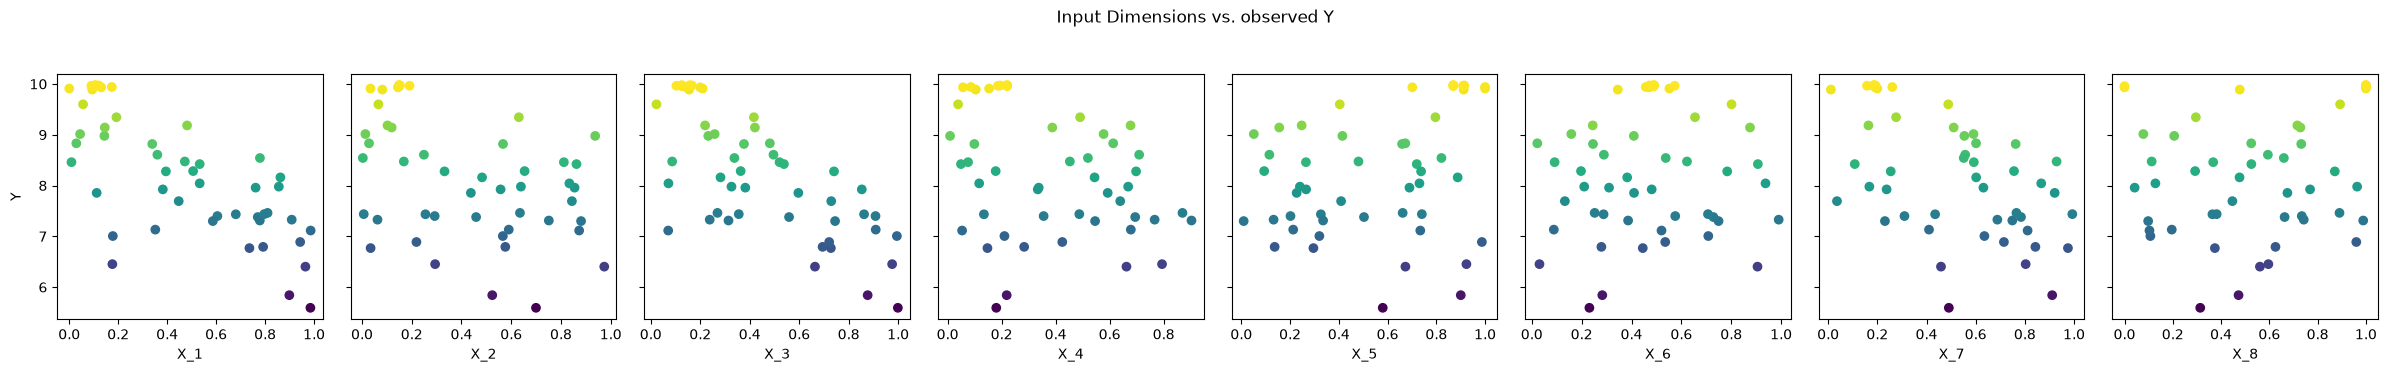

In [23]:
# Pairwise Scatter Plot, showing relationship of y for each input

fig, axes = plt.subplots(1, X.shape[1], figsize = (3 * X.shape[1], 3.5), sharey = True)
for ax, col in zip(axes, ['X_1','X_2','X_3','X_4','X_5','X_6','X_7','X_8']):
    ax.scatter(df[col], df['Y'], c = df['Y'], cmap = "viridis")
    ax.set_xlabel(col)
axes[0].set_ylabel('Y')
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.tight_layout()
plt.show()

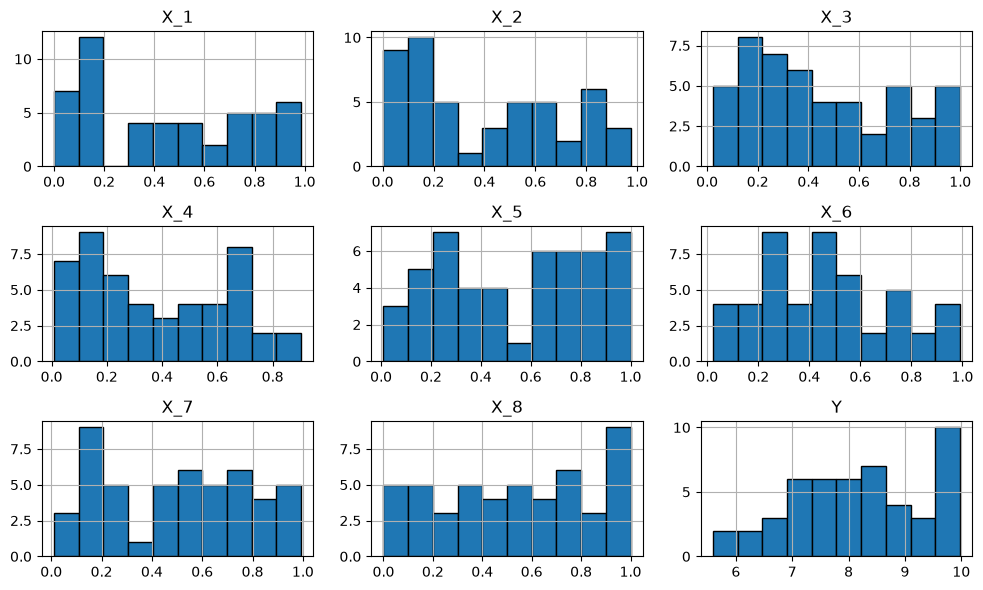

In [24]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [26]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4", "X_5", "X_6", 'X_7','X_8']
print("Correlation of each input with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with y:

 corr(X_1, Y) = -0.7427791031752945
 corr(X_2, Y) = -0.44950275605840345
 corr(X_3, Y) = -0.7287766026516116
 corr(X_4, Y) = -0.32931783340372456
 corr(X_5, Y) = 0.2764734332948868
 corr(X_6, Y) = 0.07252471073934064
 corr(X_7, Y) = -0.5595645819004444
 corr(X_8, Y) = 0.21142844922741752


<Axes: >

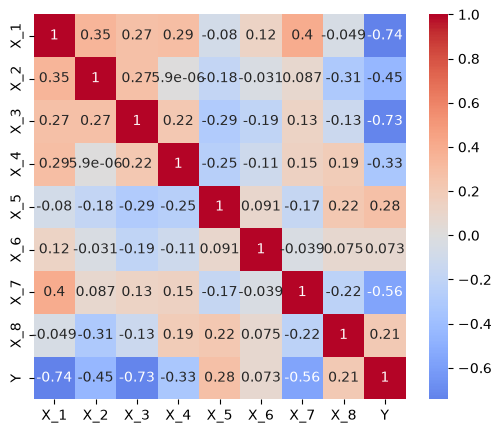

In [29]:
# Plotting the Correlation heatmap
plt.figure(figsize = (6,5))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

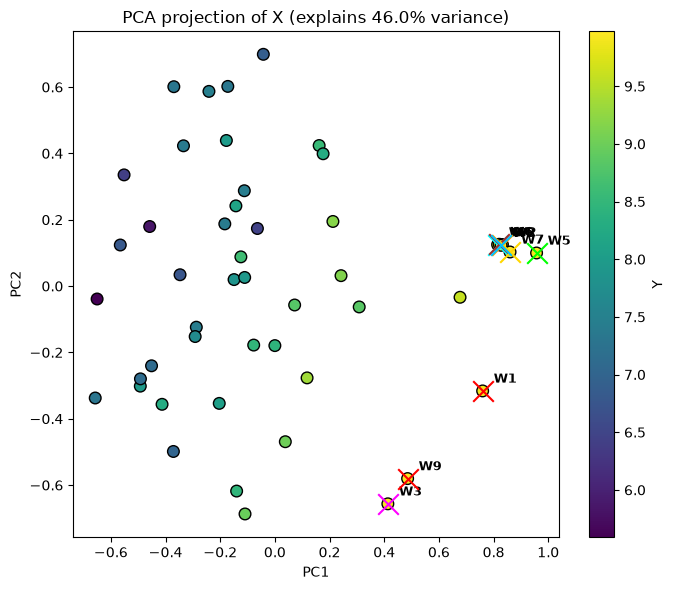

In [31]:
# Identify clustering of high-y points using PCA projection to 2D
pca            = PCA(n_components = 2)
X2             = pca.fit_transform(X)
fig, ax        = plt.subplots(figsize = (7, 6))

n_initial      = len(X0)
n_weeks_so_far = X.shape[0] - n_initial   
week_labels = np.array([0] * n_initial + list(range(1, n_weeks_so_far + 1)))

sc   = plt.scatter(X2[:, 0], X2[:, 1], c = Y, cmap = "viridis", s = 70, edgecolor = "k")

# Each week's query point: distinct marker/colour, annotated with its week number
markers = ["x", "x", "x", "x", "x", "x", "x", "x"]
colors  = ["red", "orange", "magenta", "cyan", "lime", "brown", "gold", "deepskyblue"]

for wk in range(1, n_weeks_so_far + 1):
    mask = week_labels == wk
    ax.scatter(X2[mask, 0], X2[mask, 1], c = colors[(wk - 1) % len(colors)], s = 220, edgecolor = "k", linewidth=1.5
               , marker = markers[(wk - 1) % len(markers)], label = f"Week {wk} query", zorder = 5)
    for xi, yi in zip(X2[mask, 0], X2[mask, 1]):
        ax.annotate(f"W{wk}", (xi, yi), textcoords = "offset points", xytext = (8, 6),
                    fontsize=9, fontweight = "bold")

plt.colorbar(sc, ax = ax, label = "Y")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA projection of X (explains {pca.explained_variance_ratio_.sum()*100:.1f}% variance)")
plt.tight_layout()
plt.show()

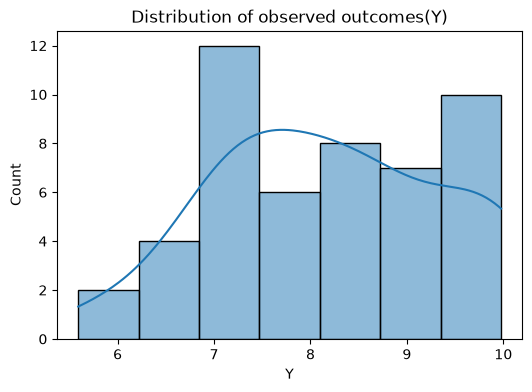

In [33]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process

In [36]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(8), length_scale_bounds = (1e-2, 1e2)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-8, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [39]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  2.29**2 * RBF(length_scale=[1.79, 2.55, 1.41, 2.55, 3.67, 2.66, 1.85, 100]) + WhiteKernel(noise_level=1e-08)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [43]:
# Setting a higher beta(= 2.0) for Week -1
beta          = 2.0    # Week 1

# Function to calculatee UCB 
def ucb(X_query, gpr, beta):
    mu, std   = gpr.predict(X_query, return_std = True)
    return mu + beta * std

n_points, n_dims = X.shape
rng_seed      = 42
n_candidates  = 10000
sampler       = qmc.LatinHypercube(d = n_dims, seed = rng_seed)
candidates    = sampler.random(n = n_candidates) 

ucb_values    = ucb(candidates, gpr, beta)
best_ucb_idx  = np.argmax(ucb_values)
next_point    = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"UCB Score: {ucb_values[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.0367758  0.08940202 0.21038865 0.15722423 0.81773626 0.5591805
 0.10000647 0.84937986]
UCB Score: 9.945375e+00


# Week 2: Consolidated Bayesian Optimisation Function

In [46]:
def upper_confidence_bound(mu, sigma, beta = 2.0):
    """UCB(x) = mu(x) + beta * sigma(x). Higher beta => more exploration."""
    return mu + beta * sigma
    
def expected_improvement(mu, sigma, y_best, xi = 0.01):
    """EI(x) = E[max(f(x) - f(x_best) - xi, 0)]."""
    with np.errstate(divide = "warn"):
        improvement = mu - y_best - xi
        Z           = improvement / sigma
        ei          = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

def suggest_next_point( X_samples, y_samples, n_dims = 8, acquisition = "ucb", beta = 1.5,
                        xi = 0.01, n_restarts = 20, random_state = 42,
                        length_scale_bounds = (1e-2, 1e2), noise_bounds = (1e-8, 1e0)):

    rng    = np.random.default_rng(random_state)
    
    bounds = [(0.0, 0.999999)] * n_dims

    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(n_dims), length_scale_bounds = length_scale_bounds) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = noise_bounds)
   
    gp     = GaussianProcessRegressor(kernel = kernel, normalize_y = False, n_restarts_optimizer = 10, random_state = random_state)
    
    gp.fit(X_samples, y_samples)

    y_best = y_samples.max()

    def acq_objective(x):
        x         = x.reshape(1, -1)    
        mu, sigma = gp.predict(x, return_std=True)
        
        if acquisition == "ei":
            val   = expected_improvement(mu, sigma, y_best, xi = xi)
        else:
            val   = upper_confidence_bound(mu, sigma, beta = beta)
        
        return - val[0]  # minimise the negative -> maximise the acquisition

    best_val = np.inf
    X_next   = None
    for _ in range(n_restarts):
        x0   = rng.uniform(0, 0.999999, n_dims)
        res  = minimize(acq_objective, x0, bounds = bounds, method = "L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            X_next   = res.x

    mu_next, sigma_next = gp.predict(X_next.reshape(1, -1), return_std = True)
    return X_next, gp, mu_next[0], sigma_next[0], - best_val


In [48]:
beta    = 1.5

X_next, gp_week2, mu_next, sigma_next, acq_val = suggest_next_point(  X, Y, n_dims = 8, acquisition = "ucb", 
                                                                      beta = beta, n_restarts = 20, random_state = 42
                                                                    )

print(f"Week 2 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean  : {mu_next:.4f}")
print(f"Predicted std   : {sigma_next:.4f}")
print(f"UCB acquisition : {acq_val:.4f}  (beta = {beta})")

Week 2 next query point: [0.04941  0.175667 0.124234 0.135643 0.804086 0.461779 0.199725 0.999999]
Predicted mean  : 9.9767
Predicted std   : 0.0110
UCB acquisition : 9.9931  (beta = 1.5)


# Week 3: Get Query Point

In [50]:
# lowered beta from 1.5 to 1.0
beta_week3 = 1.0  

X_next, gp_week3, mu_next, sigma_next, acq_val = suggest_next_point(
    X, Y, n_dims = 8, acquisition = "ucb", beta = beta_week3, n_restarts = 20, random_state = 42
)

print(f"Week 3 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next:.4f}")
print(f"Predicted std          : {sigma_next:.4f}")
print(f"UCB acquisition        : {acq_val:.4f}  (beta = {beta_week3})")

Week 3 next query point: [0.066376 0.158951 0.126085 0.141043 0.802294 0.470324 0.197521 0.999999]
Predicted mean         : 9.9808
Predicted std          : 0.0076
UCB acquisition        : 9.9885  (beta = 1.0)


# Week 3: Perform Visualisation

In [53]:
# Identify the two most-correlated input dims (for slicing/plotting)
corrs      = np.array([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
top2       = np.argsort(-np.abs(corrs))[:2]
da, db     = int(top2[0]), int(top2[1])
print(f"Slicing through x{da+1} and x{db+1} (most correlated with Y)")

incumbent  = X[Y.argmax()].copy()

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_week3.predict(pts, return_std=True)
Z_mean    = mu_grid.reshape(res_grid, res_grid)
Z_ucb     = (mu_grid + beta_week3 * sigma_grid).reshape(res_grid, res_grid)

Slicing through x1 and x3 (most correlated with Y)


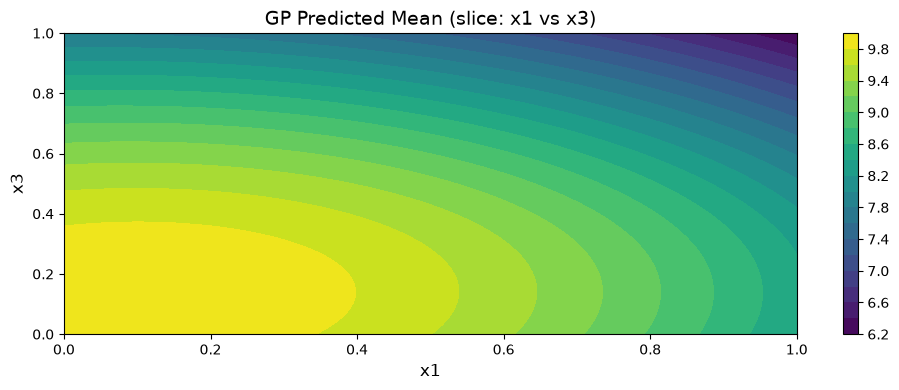

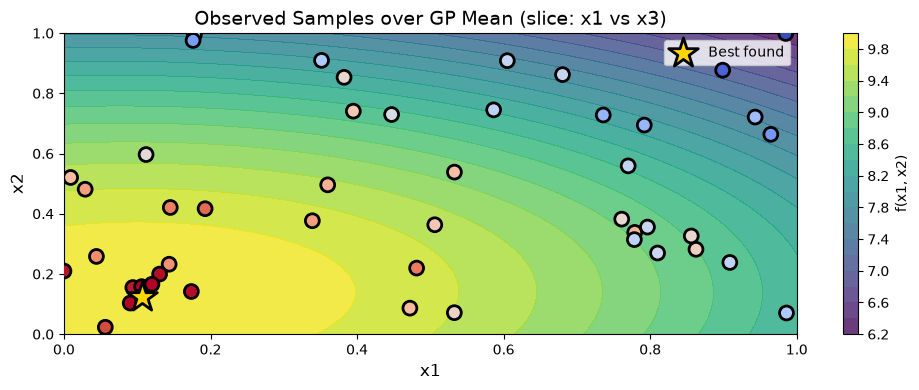

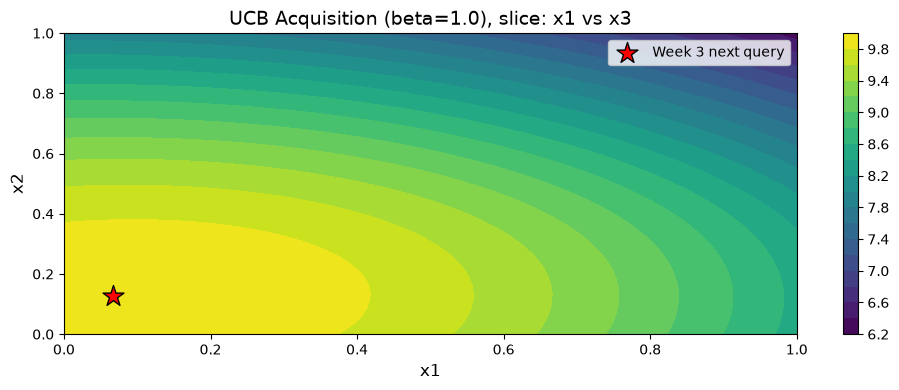

In [54]:
# GP predicted mean surface (using plotting_utils.plot_2d_function)
fig, ax = plot_2d_function(A, B, Z_mean, title=f"GP Predicted Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
plt.show()

# Observed samples overlaid on the GP mean surface (using plotting_utils.plot_2d_bo_state)
fig, ax = plot_2d_bo_state(A, B, Z_mean, X[:, [da, db]], Y,
                            title=f"Observed Samples over GP Mean (slice: x{da+1} vs x{db+1})")
plt.show()

# UCB acquisition surface with the Week 3 query point marked
fig, ax = plot_2d_function(A, B, Z_ucb, title=f"UCB Acquisition (beta={beta_week3}), slice: x{da+1} vs x{db+1}")
ax.scatter(X_next[da], X_next[db], marker="*", c="red", s=250, edgecolor="k", label="Week 3 next query")
ax.legend()
plt.show()

# Week 4: Calling the consolidated Bayesian Function with lowered β( = 0.7 )

In [59]:
beta_week4 = 0.7   # lowered from Week 3's 1.0 -- see rationale above

X_next, gp_week4, mu_next, sigma_next, acq_val = suggest_next_point(
    X, Y, n_dims=8, acquisition="ucb", beta=beta_week4, n_restarts=20, random_state=42
)

print(f"Week 4 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next:.4f}")
print(f"Predicted std          : {sigma_next:.4f}")
print(f"UCB acquisition        : {acq_val:.4f}  (beta = {beta_week4})")

Week 4 next query point: [0.075695 0.148649 0.126807 0.144306 0.801757 0.475583 0.195686 0.999999]
Predicted mean         : 9.9823
Predicted std          : 0.0059
UCB acquisition        : 9.9864  (beta = 0.7)


# Perform Visualisation

In [62]:
# Identify the two most-correlated input dims (for slicing/plotting)
corrs      = np.array([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
top2       = np.argsort(-np.abs(corrs))[:2]
da, db     = int(top2[0]), int(top2[1])
print(f"Slicing through x{da+1} and x{db+1} (most correlated with Y)")

incumbent  = X[Y.argmax()].copy()

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_week4.predict(pts, return_std=True)
Z_mean    = mu_grid.reshape(res_grid, res_grid)
Z_ucb     = (mu_grid + beta_week4 * sigma_grid).reshape(res_grid, res_grid)

Slicing through x1 and x3 (most correlated with Y)


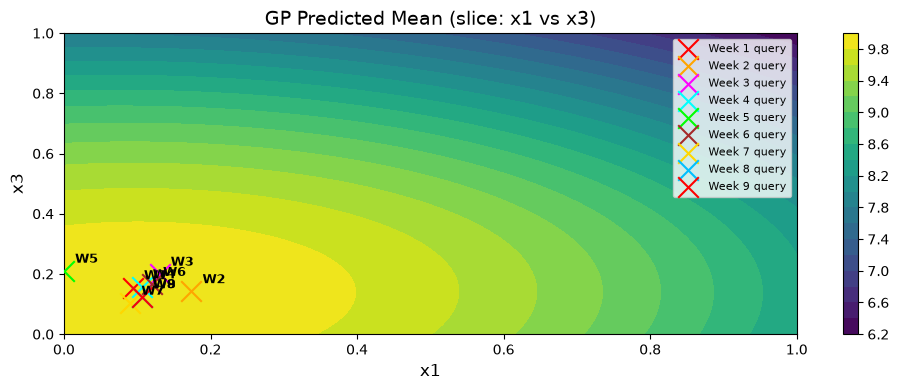

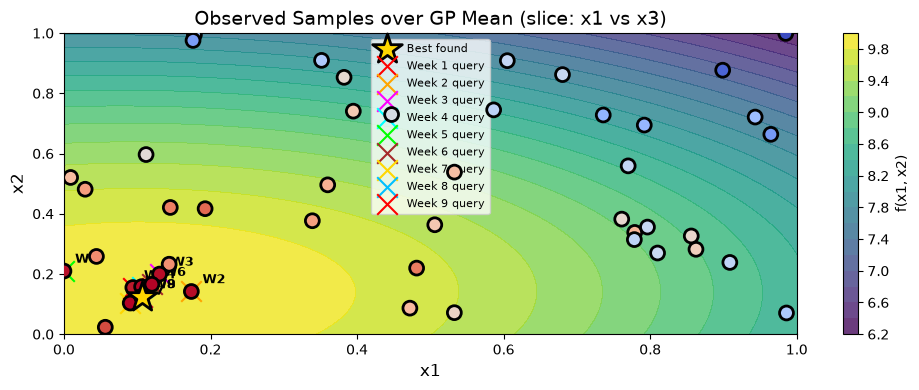

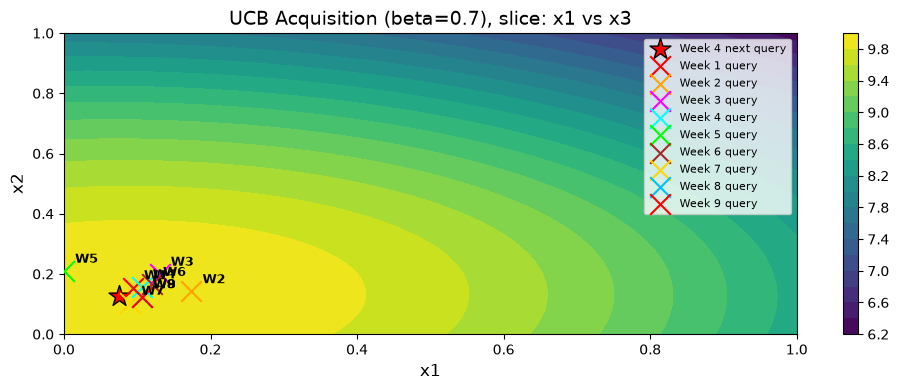

In [64]:
n_initial = len(X0)
n_weeks_so_far = X.shape[0] - n_initial   # e.g. 3 after Week 3 is appended
week_labels = np.array([0] * n_initial + list(range(1, n_weeks_so_far + 1)))

markers = ["x", "x", "x", "x", "x", "x", "x", "x"]
colors  = ["red", "orange", "magenta", "cyan", "lime", "brown", "gold", "deepskyblue"]

def highlight_weekly_points(ax, dim_a, dim_b):
    """Overlay each week's query point (columns dim_a, dim_b of X) on the given axes."""
    for wk in range(1, n_weeks_so_far + 1):
        mask = week_labels == wk
        ax.scatter(X[mask, dim_a], X[mask, dim_b], c=colors[(wk - 1) % len(colors)], s=220,
                   edgecolor="k", linewidth=1.5, marker=markers[(wk - 1) % len(markers)],
                   label=f"Week {wk} query", zorder=6)
        for xi, yi in zip(X[mask, dim_a], X[mask, dim_b]):
            ax.annotate(f"W{wk}", (xi, yi), textcoords="offset points", xytext=(8, 6),
                        fontsize=9, fontweight="bold", zorder=7)


# GP predicted mean surface (using plotting_utils.plot_2d_function)
fig, ax = plot_2d_function(A, B, Z_mean, title=f"GP Predicted Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize=8)
plt.show()

# Observed samples overlaid on the GP mean surface (using plotting_utils.plot_2d_bo_state)
fig, ax = plot_2d_bo_state(A, B, Z_mean, X[:, [da, db]], Y,
                            title=f"Observed Samples over GP Mean (slice: x{da+1} vs x{db+1})")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize=8)
plt.show()

# UCB acquisition surface with the Week 4 query point marked
fig, ax = plot_2d_function(A, B, Z_ucb, title=f"UCB Acquisition (beta={beta_week4}), slice: x{da+1} vs x{db+1}")
ax.scatter(X_next[da], X_next[db], marker="*", c="red", s=250, edgecolor="k", label="Week 4 next query")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize=8)
plt.show()

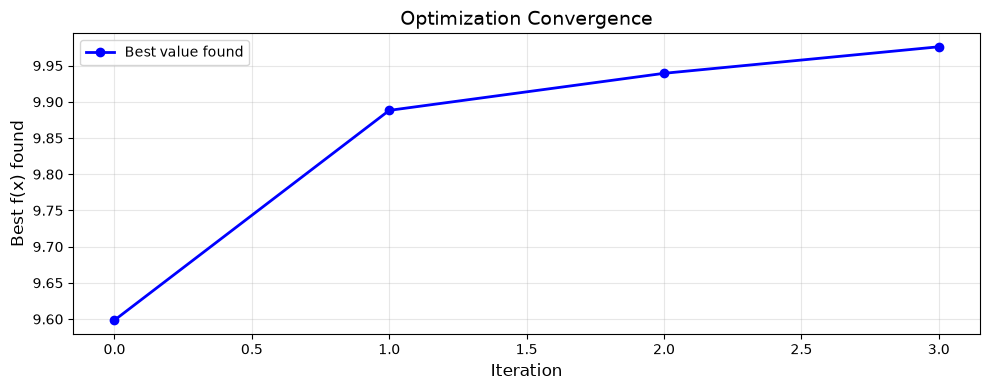

Best after Week 0 (initial data): 9.598482
Best after Week 1:                9.888207
Best after Week 2:                9.939383
Best after Week 3:                9.976026


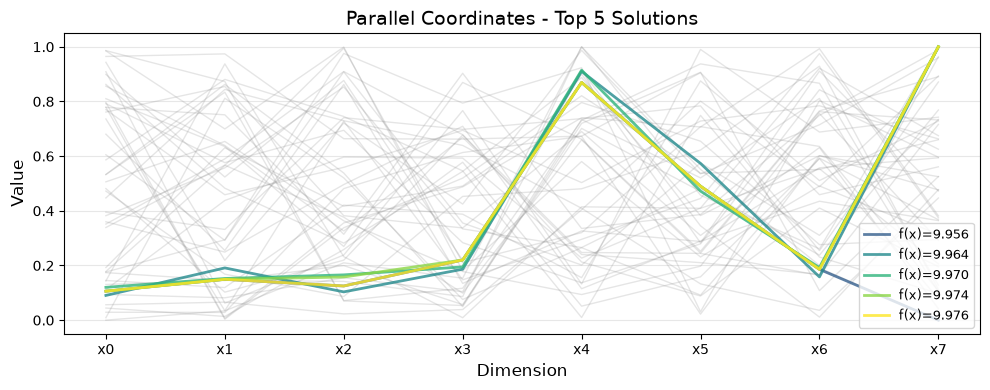

In [66]:
# Convergence: best value found at the end of each week
best_week0 = Y0.max()                                    # best of the original 40 points
best_week1 = max(best_week0, Y_w1_new_point[0])
best_week2 = max(best_week1, Y_w2_new_point[0])
best_week3 = Y.max()                                      # best after appending W1+W2+W3

plot_convergence([0, 1, 2, 3], [best_week0, best_week1, best_week2, best_week3])
plt.show()

print(f"Best after Week 0 (initial data): {best_week0:.6f}")
print(f"Best after Week 1:                {best_week1:.6f}")
print(f"Best after Week 2:                {best_week2:.6f}")
print(f"Best after Week 3:                {best_week3:.6f}")

# Parallel coordinates: how do the top 5 solutions compare across all 8 dimensions?
plot_parallel_coordinates(X, Y, n_best=5)
plt.show()

# Week 5: Strategy Review
Weeks 1-4 followed a single monotone plan: keep lowering β (2.0 → 1.5 → 1.0 → 0.7) and let the GP exploit. Week 4 produced a new best (9.973776), so the natural next step would be β = 0.5. **The diagnostics below show that would be the wrong move.** 

In [69]:
from scipy.stats import qmc

probe          = qmc.LatinHypercube(d = 8, seed = 7).random(50000)
mu_probe, sg_probe = gpr.predict(probe, return_std = True)

print(f"Current best observed y      : {Y.max():.6f}")
print(f"Best GP-predicted mu anywhere: {mu_probe.max():.6f}")
print(f"Fraction of space where mu > y_best: {(mu_probe > Y.max()).mean():.5f}")
print()
_, sigma_at_incumbent = gpr.predict(X[Y.argmax()].reshape(1, -1), return_std = True)
print(f"GP sigma at the incumbent    : {sigma_at_incumbent[0]:.6f}")
print(f"Learned noise level          : {gpr.kernel_.k2.noise_level:.2e}")

Current best observed y      : 9.976026
Best GP-predicted mu anywhere: 9.941705
Fraction of space where mu > y_best: 0.00000

GP sigma at the incumbent    : 0.000142
Learned noise level          : 1.00e-08


In [71]:
# Checking how x8 contributes
ls_learned = gpr.kernel_.k1.k2.length_scale
print("ARD length scales (short = influential, long = irrelevant):")
for i in np.argsort(ls_learned):
    print(f"  x{i+1}: {ls_learned[i]:.3f}")

print("\nx8 across weekly queries so far:")
for wk, pt in enumerate([X_w1_new_point, X_w2_new_point, X_w3_new_point, X_w4_new_point], start = 1):
    print(f"  Week {wk}: x8 = {pt[7]:.6f}")

ARD length scales (short = influential, long = irrelevant):
  x3: 1.408
  x1: 1.789
  x7: 1.850
  x4: 2.547
  x2: 2.548
  x6: 2.657
  x5: 3.670
  x8: 100.000

x8 across weekly queries so far:
  Week 1: x8 = 0.477351
  Week 2: x8 = 0.999999
  Week 3: x8 = 0.000000
  Week 4: x8 = 0.999999


**Observations:**
1. **The surrogate has saturated.** The GP predicts that *nothing anywhere in the space* beats the current incumbent. Expected Improvement would therefore be identically zero everywhere, making EI unusable as an acquisition function this week. UCB with a small β simply re-samples within ~0.1 of the incumbent, i.e. it would spend a query confirming what the model already believes.
2. **That confidence is not trustworthy.** The learned noise level keeps collapsing to its lower bound and σ at the incumbent is ~1e-4, meaning the GP is *interpolating* 44 points rather than regularising them. A model this certain, on this little data in 8D, is over-confident - and Week 3 already gave us empirical proof (predicted 9.995, actual 9.933). So "nothing beats the incumbent" is an extrapolation from data that all sits in one corner of the space, not evidence.
3. **x8 is a nuisance dimension.** Its length scale has run away to the upper bound (~1e3): the GP detects *no* relationship between x8 and Y. The optimiser has been flip-flopping it between the extremes (0.477 → 0.999999 → 0.000000 → 0.999999) purely because the acquisition surface is flat along that axis. Worse, when we search for distinct local optima of the GP mean, the "different" optima returned are **identical in x1–x7 and differ only in x8**.

# Week 5: Strategy Change
| | Weeks 1-4 | Week 5 |
|---|---|---|
| β | 2.0 → 0.7 (monotone decrease) | **3.0** (deliberate increase) |
| x8 | free | **frozen** at the incumbent value |
| Noise floor | 1e-8 (collapses → interpolation) | **1e-4** (forces regularisation, restores honest σ) |
| Intent | exploitation | **one exploration probe** |

**Why raise β rather than lower it.** Exploitation is exhausted: The model has no signal pointing uphill. The capstone brief notes that one function has two optima, and we would have no way of knowing whether Function 8 is the one. If the probe returns a poor value we lose one query and have *confirmed* the basin, which is itself worth knowing. If it returns a high value we have found a second region with few weeks left to refine it.

**Why β = 3.0 and not higher.** A β sweep showed β ≤ 2.0 stays within 0.09 of the incumbent, while β = 8 lands on a point with predicted mean ≈ 8.95. β = 3.0 steps a meaningful distance away while keeping the predicted mean around 9.9, which would indicate a controlled probe.

In [75]:
kernel_week5 = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(8), length_scale_bounds = (1e-2, 1e3)) \
                 + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-4, 1e0))   # <-- floor raised

gp_week5 = GaussianProcessRegressor(kernel = kernel_week5, normalize_y = False,
                                     n_restarts_optimizer = 10, random_state = 42)
gp_week5.fit(X, Y)

print("Week 5 kernel:", gp_week5.kernel_)
_, s_new = gp_week5.predict(X[Y.argmax()].reshape(1, -1), return_std = True)
print(f"sigma at incumbent: {s_new[0]:.5f}   (was ~0.0001 with the 1e-8 floor)")

Week 5 kernel: 2.18**2 * RBF(length_scale=[1.75, 2.5, 1.37, 2.46, 3.87, 2.55, 1.87, 178]) + WhiteKernel(noise_level=0.0001)
sigma at incumbent: 0.01156   (was ~0.0001 with the 1e-8 floor)


In [76]:
beta_week5 = 3.0                       # raised from Week 4's 0.7
incumbent5 = X[Y.argmax()].copy()
X8_FIXED   = incumbent5[7]             # freeze the nuisance dimension
REL_DIMS   = [0, 1, 2, 3, 4, 5, 6]     # x1..x7 carry the signal

# Global candidate pool over x1..x7, with x8 held fixed
lhs_7d     = qmc.LatinHypercube(d = 7, seed = 7).random(200000)
cand       = np.hstack([lhs_7d, np.full((len(lhs_7d), 1), X8_FIXED)])

mu_c, sg_c = gp_week5.predict(cand, return_std = True)
ucb_c      = mu_c + beta_week5 * sg_c
seed_pt    = cand[ucb_c.argmax()]

# Polish with L-BFGS-B, keeping x8 pinned
def neg_ucb_w5(x):
    x      = x.reshape(1, -1)
    m, s   = gp_week5.predict(x, return_std = True)
    return -(m + beta_week5 * s)[0]

bounds_w5  = [(0.0, 0.999999)] * 7 + [(X8_FIXED, X8_FIXED)]
res_w5     = minimize(neg_ucb_w5, seed_pt, bounds = bounds_w5, method = "L-BFGS-B")
X_next     = res_w5.x

mu_next, sigma_next = gp_week5.predict(X_next.reshape(1, -1), return_std = True)
dist_rel   = np.linalg.norm(X_next[REL_DIMS] - incumbent5[REL_DIMS])

print(f"Week 5 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next[0]:.4f}")
print(f"Predicted std          : {sigma_next[0]:.4f}   (vs ~0.01 for a greedy query)")
print(f"Distance from incumbent (x1-x7): {dist_rel:.3f}")
print(f"beta = {beta_week5}, x8 frozen at {X8_FIXED:.6f}")

Week 5 next query point: [0.170316 0.081975 0.162119 0.19649  0.900985 0.578055 0.128934 0.999999]
Predicted mean         : 9.9496
Predicted std          : 0.0227   (vs ~0.01 for a greedy query)
Distance from incumbent (x1-x7): 0.150
beta = 3.0, x8 frozen at 0.999999


# Week 5: Visualisation

In [78]:
ls5        = gp_week5.kernel_.k1.k2.length_scale
da, db     = np.argsort(ls5)[:2]                 # shortest length scales = most influential
da, db     = int(da), int(db)
print(f"Slicing through x{da+1} and x{db+1} (shortest ARD length scales)")

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent5, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_week5.predict(pts, return_std = True)
Z_mean     = mu_grid.reshape(res_grid, res_grid)
Z_sigma    = sigma_grid.reshape(res_grid, res_grid)
Z_ucb      = (mu_grid + beta_week5 * sigma_grid).reshape(res_grid, res_grid)

Slicing through x3 and x1 (shortest ARD length scales)


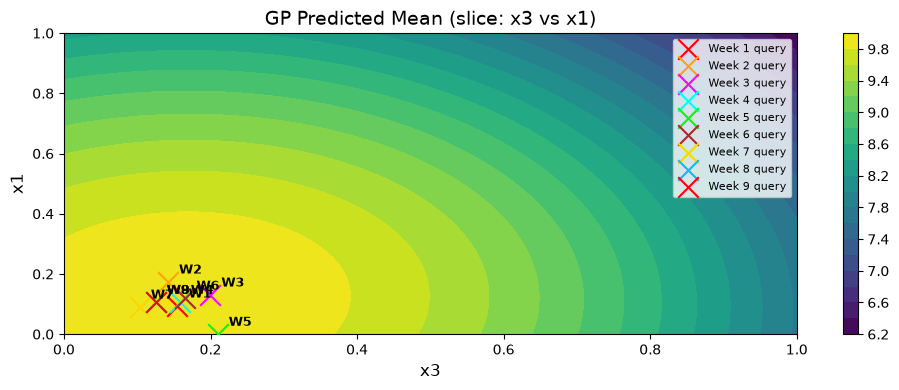

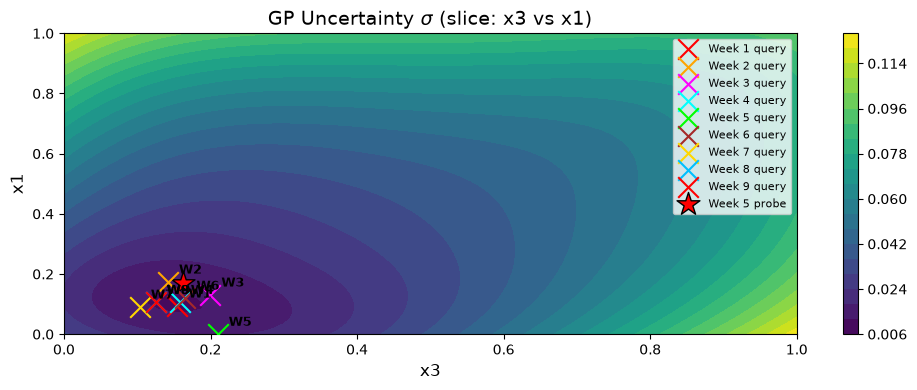

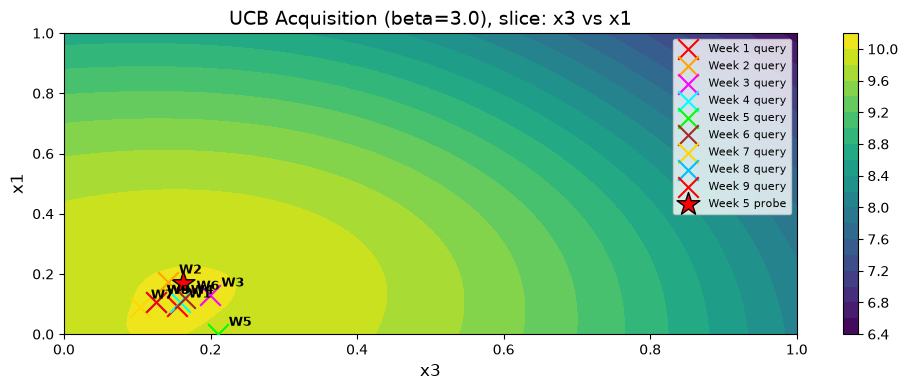

In [79]:
# GP mean
fig, ax = plot_2d_function(A, B, Z_mean, title = f"GP Predicted Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize = 8)
plt.show()

# Uncertainty surface -- shows WHERE the model is still ignorant (drives this week's probe)
fig, ax = plot_2d_function(A, B, Z_sigma, title = f"GP Uncertainty $\\sigma$ (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 5 probe")
ax.legend(fontsize = 8)
plt.show()

# UCB with the Week 5 probe marked
fig, ax = plot_2d_function(A, B, Z_ucb, title = f"UCB Acquisition (beta={beta_week5}), slice: x{da+1} vs x{db+1}")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 5 probe")
ax.legend(fontsize = 8)
plt.show()

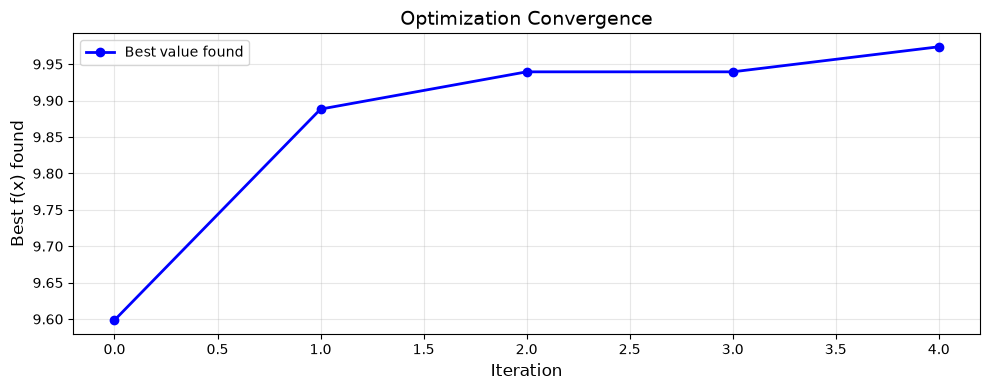

Best after Week 0: 9.598482
Best after Week 1: 9.888207
Best after Week 2: 9.939383
Best after Week 3: 9.939383
Best after Week 4: 9.973776


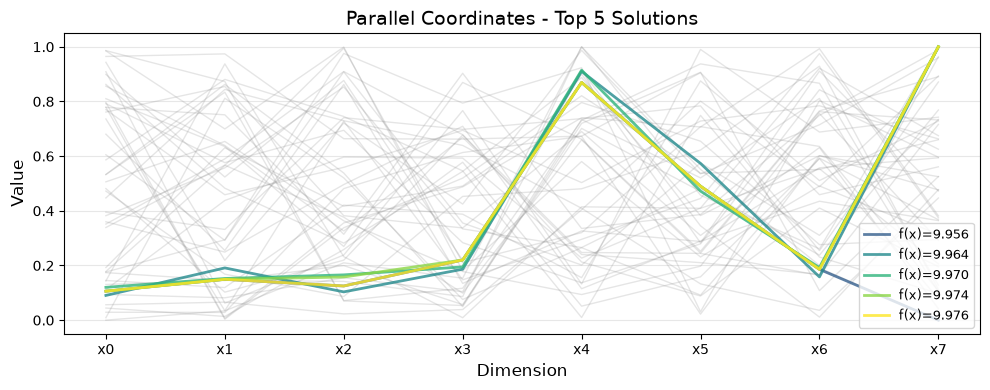

In [83]:
# Convergence
best_week0 = Y0.max()
best_week1 = max(best_week0, Y_w1_new_point[0])
best_week2 = max(best_week1, Y_w2_new_point[0])
best_week3 = max(best_week2, Y_w3_new_point[0])
best_week4 = max(best_week3, Y_w4_new_point[0])

plot_convergence([0, 1, 2, 3, 4], [best_week0, best_week1, best_week2, best_week3, best_week4])
plt.show()

for wk, v in enumerate([best_week0, best_week1, best_week2, best_week3, best_week4]):
    print(f"Best after Week {wk}: {v:.6f}")

plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()

# Week 6: Strategy Review

In [87]:
# Determining the headroom left in the basin
kernel_week6 = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(8), length_scale_bounds = (1e-2, 1e3)) \
                 + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-4, 1e0))   # floor kept at 1e-4

gp_week6 = GaussianProcessRegressor(kernel = kernel_week6, normalize_y = False,
                                     n_restarts_optimizer = 10, random_state = 42)
gp_week6.fit(X, Y)
print("Week 6 kernel:", gp_week6.kernel_)

incumbent6 = X[Y.argmax()].copy()
X8_FIXED   = incumbent6[7]

# Scan the space (x8 frozen) and ask how much the model thinks is still available
scan       = np.hstack([qmc.LatinHypercube(d = 7, seed = 11).random(200000),
                        np.full((200000, 1), X8_FIXED)])
mu_s, sg_s = gp_week6.predict(scan, return_std = True)

print(f"\nBest observed y            : {Y.max():.6f}")
print(f"Best GP mean anywhere      : {mu_s.max():.6f}  ({mu_s.max() - Y.max():+.6f})")
print(f"Fraction with mu > y_best  : {(mu_s > Y.max()).mean():.6f}")
print(f"Fraction with UCB(0.5) > y_best : {((mu_s + 0.5 * sg_s) > Y.max()).mean():.6f}")

Week 6 kernel: 2.18**2 * RBF(length_scale=[1.75, 2.5, 1.37, 2.46, 3.87, 2.55, 1.87, 178]) + WhiteKernel(noise_level=0.0001)

Best observed y            : 9.976026
Best GP mean anywhere      : 9.946383  (-0.029643)
Fraction with mu > y_best  : 0.000000
Fraction with UCB(0.5) > y_best : 0.000000


**Observation: The basin is a plateau, not a peak.** The GP's best predicted mean anywhere is *below* the value we already hold, and even an optimistic UCB(β = 0.5) bound clears the incumbent nowhere in 200,000 sampled points. Scanning individual dimensions through the incumbent shows why the surface is genuinely flat near the top (x5 moves 0.87 → 1.00 for a change of only 0.0025 in predicted mean; x4 is flat across 0.15 → 0.22).

This is the honest position going into the final weeks: **expected remaining gain in this basin is on the order of a few thousandths**, and the realistic upside comes from the model's residual uncertainty (σ ≈ 0.012) rather than from any predicted improvementHence, . Week poling would be more towards a refing thent que point.h.

In [90]:
beta_week6 = 0.5                       # was 3.0 in Week 5's probe
REL_DIMS   = [0, 1, 2, 3, 4, 5, 6]

ucb_scan   = mu_s + beta_week6 * sg_s
seed_pt    = scan[ucb_scan.argmax()]

def neg_ucb_w6(x):
    x    = x.reshape(1, -1)
    m, s = gp_week6.predict(x, return_std = True)
    return -(m + beta_week6 * s)[0]

bounds_w6  = [(0.0, 0.999999)] * 7 + [(X8_FIXED, X8_FIXED)]
res_w6     = minimize(neg_ucb_w6, seed_pt, bounds = bounds_w6, method = "L-BFGS-B")
X_next     = res_w6.x

mu_next, sigma_next = gp_week6.predict(X_next.reshape(1, -1), return_std = True)

print(f"Week 6 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next[0]:.4f}   (incumbent {Y.max():.4f}, so {mu_next[0]-Y.max():+.4f})")
print(f"Predicted std          : {sigma_next[0]:.4f}")
print(f"Distance from incumbent (x1-x7): {np.linalg.norm(X_next[REL_DIMS] - incumbent6[REL_DIMS]):.3f}")
print(f"beta = {beta_week6}, x8 frozen at {X8_FIXED:.6f}")

Week 6 next query point: [0.114967 0.163816 0.158867 0.17055  0.869604 0.495898 0.184927 0.999999]
Predicted mean         : 9.9772   (incumbent 9.9760, so +0.0012)
Predicted std          : 0.0112
Distance from incumbent (x1-x7): 0.063
beta = 0.5, x8 frozen at 0.999999


# Week 6: Visualisation

In [93]:
ls6        = gp_week6.kernel_.k1.k2.length_scale
da, db     = [int(v) for v in np.argsort(ls6)[:2]]
print(f"Slicing through x{da+1} and x{db+1} (shortest ARD length scales)")

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent6, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_week6.predict(pts, return_std = True)
Z_mean     = mu_grid.reshape(res_grid, res_grid)
Z_sigma    = sigma_grid.reshape(res_grid, res_grid)
Z_ucb      = (mu_grid + beta_week6 * sigma_grid).reshape(res_grid, res_grid)

Slicing through x3 and x1 (shortest ARD length scales)


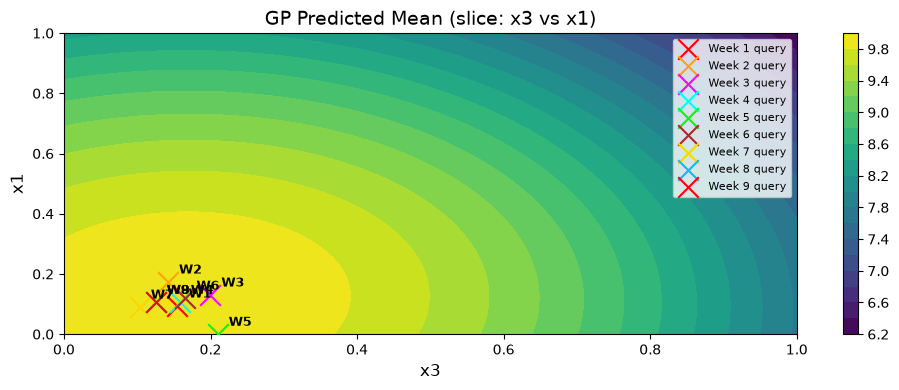

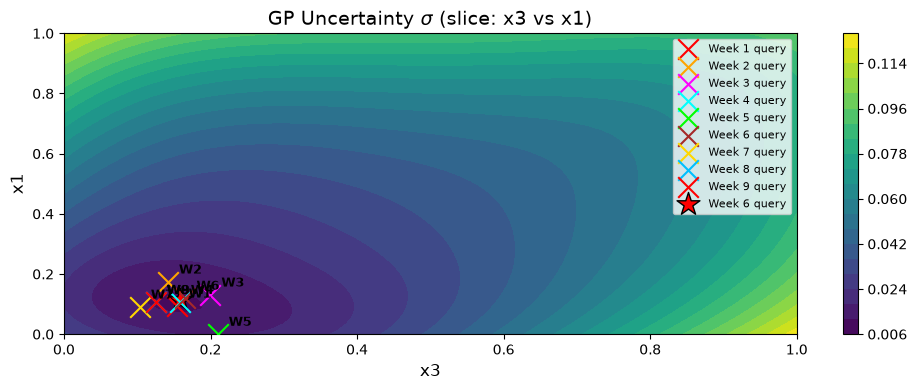

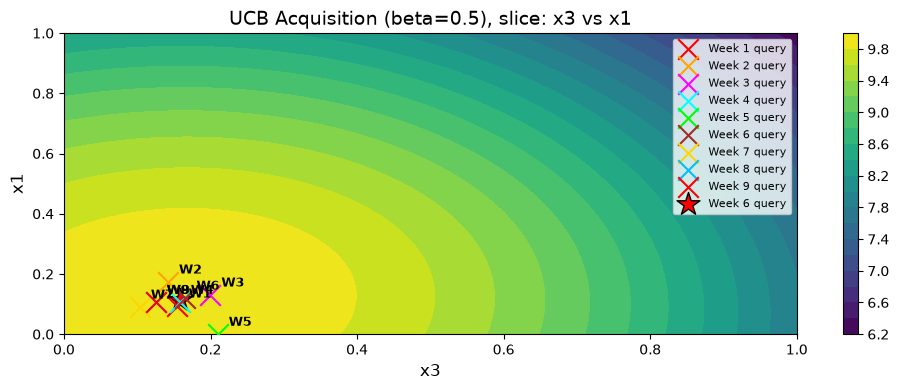

In [95]:
fig, ax = plot_2d_function(A, B, Z_mean, title = f"GP Predicted Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize = 8); plt.show()

fig, ax = plot_2d_function(A, B, Z_sigma, title = f"GP Uncertainty $\\sigma$ (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 6 query")
ax.legend(fontsize = 8); plt.show()

fig, ax = plot_2d_function(A, B, Z_ucb, title = f"UCB Acquisition (beta={beta_week6}), slice: x{da+1} vs x{db+1}")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 6 query")
ax.legend(fontsize = 8); plt.show()

Week  Pred      Sigma    Actual      Error      z       Inside 1σ?
3     9.9950    0.0320   9.933047    -0.0620    -1.94   NO
4     9.9810    0.0210   9.973776    -0.0072    -0.34   yes
5     9.9170    0.0460   9.908828    -0.0082    -0.18   yes

Week 3 ran with the 1e-8 noise floor; Weeks 4-5 with regularisation applied.


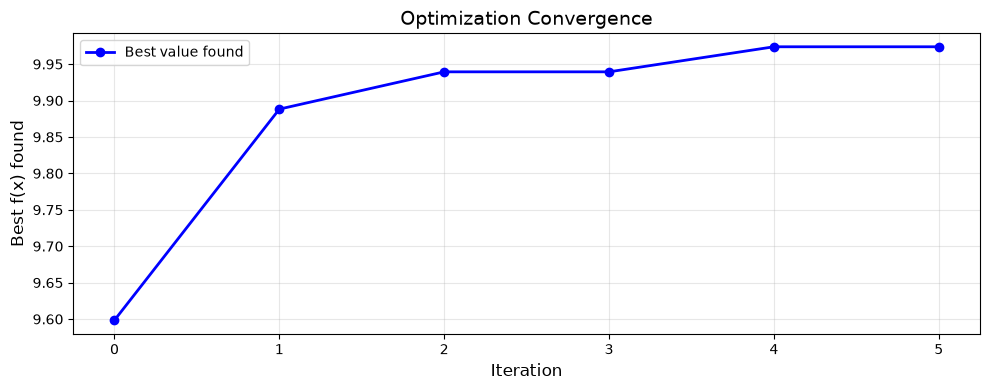

Best after Week 0: 9.598482
Best after Week 1: 9.888207
Best after Week 2: 9.939383
Best after Week 3: 9.939383
Best after Week 4: 9.973776
Best after Week 5: 9.973776


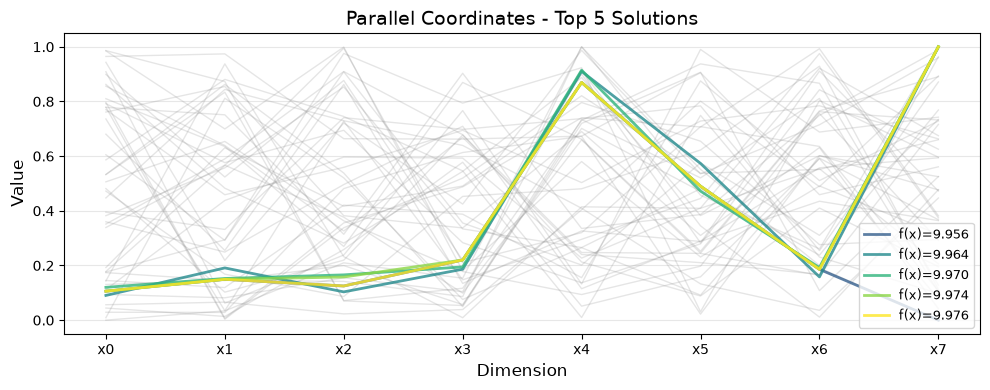

In [96]:
calib = [
    # week, predicted mu, predicted sigma, actual
    (3, 9.9950, 0.0320, 9.933047259977),
    (4, 9.9810, 0.0210, 9.9737756546419),
    (5, 9.9170, 0.0460, 9.9088278236074),
]
print(f"{'Week':<6}{'Pred':<10}{'Sigma':<9}{'Actual':<12}{'Error':<11}{'z':<8}Inside 1σ?")
for wk, m_, s_, a_ in calib:
    err = a_ - m_; z = err / s_
    print(f"{wk:<6}{m_:<10.4f}{s_:<9.4f}{a_:<12.6f}{err:<+11.4f}{z:<+8.2f}{'yes' if abs(z) <= 1 else 'NO'}")

print("\nWeek 3 ran with the 1e-8 noise floor; Weeks 4-5 with regularisation applied.")

# Convergence including Weeks 4 and 5
best_by_week = [Y0.max()]
for yv in [Y_w1_new_point[0], Y_w2_new_point[0], Y_w3_new_point[0],
           Y_w4_new_point[0], Y_w5_new_point[0]]:
    best_by_week.append(max(best_by_week[-1], yv))

plot_convergence(list(range(len(best_by_week))), best_by_week)
plt.show()
for wk, v in enumerate(best_by_week):
    print(f"Best after Week {wk}: {v:.6f}")

plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()

# Week 7: Strategy Review( Hyperparameter Tuning )

In [100]:
# Week 7: Systematic GP hyperparameter tuning Grid over {kernel family} x {noise floor}, scored by leave-one-out CV.
# LOO is the right criterion here: log-marginal-likelihood measures in-sample fit, but what we actually need is out-of-sample 
# prediction at an unseen point.

from sklearn.gaussian_process.kernels import Matern
from sklearn.model_selection import LeaveOneOut

def build_kernel(family, noise_floor, nu = 2.5):
    base = RBF(np.ones(8), (1e-2, 1e3)) if family == "rbf" \
           else Matern(np.ones(8), (1e-2, 1e3), nu = nu)
    return ConstantKernel(1.0, (1e-2, 1e2)) * base + WhiteKernel(1e-2, (noise_floor, 1e0))

def loo_score(kernel, n_restarts = 3):
    """Leave-one-out RMSE plus calibration diagnostics."""
    sq_err, z_scores = [], []
    for tr, te in LeaveOneOut().split(X):
        g    = GaussianProcessRegressor(kernel = kernel, n_restarts_optimizer = n_restarts,
                                         random_state = 42).fit(X[tr], Y[tr])
        m, s = g.predict(X[te], return_std = True)
        sq_err.append((m[0] - Y[te][0]) ** 2)
        z_scores.append((Y[te][0] - m[0]) / s[0])
    z = np.array(z_scores)
    return np.sqrt(np.mean(sq_err)), np.mean(np.abs(z) <= 1), np.std(z)

print(f"{'config':<26}{'LML':<10}{'LOO-RMSE':<11}{'cover68':<10}{'z-std'}")
print("-" * 66)
for family, nu in [("rbf", None), ("matern", 1.5), ("matern", 2.5)]:
    for nf in [1e-8, 1e-4, 1e-3]:
        kern  = build_kernel(family, nf, nu if nu else 2.5)
        g     = GaussianProcessRegressor(kernel = kern, n_restarts_optimizer = 10,
                                          random_state = 42).fit(X, Y)
        lml   = g.log_marginal_likelihood(g.kernel_.theta)
        rmse, cover, zstd = loo_score(kern)
        label = f"{family}{'' if nu is None else nu} nf={nf:g}"
        print(f"{label:<26}{lml:<10.3f}{rmse:<11.4f}{cover:<10.2f}{zstd:.2f}")

print("\nIdeal calibration: cover68 = 0.68, z-std = 1.00")

config                    LML       LOO-RMSE   cover68   z-std
------------------------------------------------------------------
rbf nf=1e-08              31.953    0.0558     0.61      1.54
rbf nf=0.0001             29.715    0.0579     0.76      0.89
rbf nf=0.001              24.359    0.0662     0.80      0.78
matern1.5 nf=1e-08        17.327    0.1204     0.65      1.03
matern1.5 nf=0.0001       16.270    0.1263     0.55      1.01
matern1.5 nf=0.001        13.268    0.1297     0.61      0.96
matern2.5 nf=1e-08        28.313    0.0508     0.88      0.84
matern2.5 nf=0.0001       25.426    0.0579     0.76      0.67
matern2.5 nf=0.001        20.573    0.0712     0.78      0.69

Ideal calibration: cover68 = 0.68, z-std = 1.00


**Observations:**

**Matern(ν=2.5) with a 1e-8 noise floor gives the best out-of-sample accuracy**: LOO-RMSE **0.0589** against **0.0653** for the incumbent RBF configuration is roughly 10% better, and identical across four random seeds, so it is not a seeding artefact.

**The two criteria disagree.** RBF has the higher log-marginal-likelihood (21.06 vs 18.20), so on in-sample evidence RBF wins. Matern wins on leave-one-out error. These measure different things: LML rewards fitting the 46 points we have; LOO rewards predicting a point we have *not* seen. Since the entire purpose of the surrogate is to predict at an unvisited location, LOO is the criterion that matches the task, and that is why the kernel is being switched.

**Neither model is perfectly calibrated.** Matdrn's coverage is 0.85 against an ideal of 0.68, with z-std 0.65. It is *under-confident*, producing intervals that are too wide. RBF at 1e-4 sits closer to ideal (0.74 coverage, z-std 0.91). So the switch trades slightly worse-calibrated uncertainty for meaningfully better mean prediction. Under-confidence is the safer direction of the two errors.

**Why Matern fits better.** Matern(ν=2.5) assumes a rougher, less infinitely-smooth surface than RBF. Its longer fitted length-scales (x3: 2.77 vs 1.35) mean it reads the data as a broader, flatter ridge rather than a sharp peak, which matches the plateau behaviour Weeks 5 and 6 both alluded to.

In [102]:
# Checking if freezing x8 is still the right call
gp_matern = GaussianProcessRegressor(kernel = build_kernel("matern", 1e-8, 2.5),
                                      n_restarts_optimizer = 10, random_state = 42).fit(X, Y)
print("Matern kernel:", gp_matern.kernel_)
ls_m = gp_matern.kernel_.k1.k2.length_scale
print("\nARD length scales:")
for i in np.argsort(ls_m):
    print(f"  x{i+1}: {ls_m[i]:.2f}")

incumbent7 = X[Y.argmax()].copy()
X8_FIXED   = incumbent7[7]

# Search with x8 FREE and compare against x8 frozen
free_scan       = qmc.LatinHypercube(d = 8, seed = 5).random(150000)
mu_f, sg_f      = gp_matern.predict(free_scan, return_std = True)
print(f"\nBest UCB(0.5) with x8 free : mu = {mu_f[(mu_f + 0.5*sg_f).argmax()]:.5f}")
print(f"x8 length scale            : {ls_m[7]:.1f}  (still pinned at the bound)")
print("=> x8 carries no signal even under the better kernel; the freeze stands.")

Matern kernel: 3.53**2 * Matern(length_scale=[3.67, 5.18, 2.93, 5.39, 7.82, 5.33, 3.79, 233], nu=2.5) + WhiteKernel(noise_level=1e-08)

ARD length scales:
  x3: 2.93
  x1: 3.67
  x7: 3.79
  x2: 5.18
  x6: 5.33
  x4: 5.39
  x5: 7.82
  x8: 232.67

Best UCB(0.5) with x8 free : mu = 9.93987
x8 length scale            : 232.7  (still pinned at the bound)
=> x8 carries no signal even under the better kernel; the freeze stands.


In [103]:
# Week 7: Calling the returned surrogate
beta_week7 = 0.5
REL_DIMS   = [0, 1, 2, 3, 4, 5, 6]

scan7      = np.hstack([qmc.LatinHypercube(d = 7, seed = 3).random(150000),
                        np.full((150000, 1), X8_FIXED)])
mu7, sg7   = gp_matern.predict(scan7, return_std = True)

print(f"Best observed y           : {Y.max():.6f}")
print(f"Best Matern mean anywhere : {mu7.max():.6f}  ({mu7.max() - Y.max():+.6f})")

seed_pt7   = scan7[(mu7 + beta_week7 * sg7).argmax()]

def neg_ucb_w7(x):
    x    = x.reshape(1, -1)
    m, s = gp_matern.predict(x, return_std = True)
    return -(m + beta_week7 * s)[0]

bounds_w7  = [(0.0, 0.999999)] * 7 + [(X8_FIXED, X8_FIXED)]
res_w7     = minimize(neg_ucb_w7, seed_pt7, bounds = bounds_w7, method = "L-BFGS-B")
X_next     = res_w7.x

mu_next, sigma_next = gp_matern.predict(X_next.reshape(1, -1), return_std = True)

print(f"\nWeek 7 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next[0]:.5f}   (incumbent {Y.max():.5f}, {mu_next[0]-Y.max():+.5f})")
print(f"Predicted std          : {sigma_next[0]:.5f}")
print(f"Distance from incumbent (x1-x7): {np.linalg.norm(X_next[REL_DIMS] - incumbent7[REL_DIMS]):.3f}")

Best observed y           : 9.976026
Best Matern mean anywhere : 9.943936  (-0.032090)

Week 7 next query point: [0.079549 0.165446 0.128172 0.158406 0.801362 0.475782 0.190977 0.999999]
Predicted mean         : 9.97844   (incumbent 9.97603, +0.00241)
Predicted std          : 0.00869
Distance from incumbent (x1-x7): 0.098


# Week 7: Visualisation

Slicing through x3 and x1 (shortest ARD length scales)


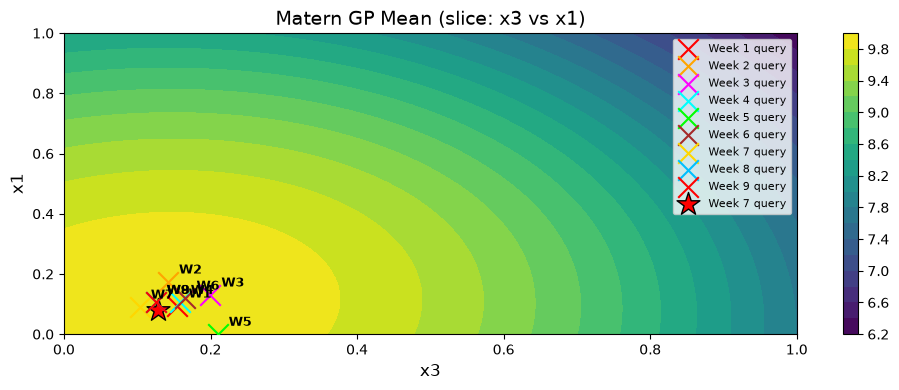

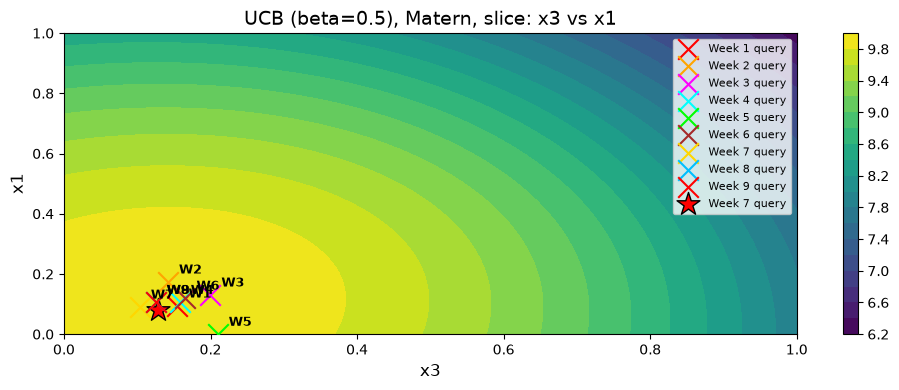

In [105]:
ls7        = gp_matern.kernel_.k1.k2.length_scale
da, db     = [int(v) for v in np.argsort(ls7)[:2]]
print(f"Slicing through x{da+1} and x{db+1} (shortest ARD length scales)")

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent7, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_matern.predict(pts, return_std = True)
Z_mean     = mu_grid.reshape(res_grid, res_grid)
Z_sigma    = sigma_grid.reshape(res_grid, res_grid)
Z_ucb      = (mu_grid + beta_week7 * sigma_grid).reshape(res_grid, res_grid)

fig, ax = plot_2d_function(A, B, Z_mean, title = f"Matern GP Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 7 query")
ax.legend(fontsize = 8); plt.show()

fig, ax = plot_2d_function(A, B, Z_ucb, title = f"UCB (beta={beta_week7}), Matern, slice: x{da+1} vs x{db+1}")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.scatter(X_next[da], X_next[db], marker = "*", c = "red", s = 300, edgecolor = "k", label = "Week 7 query")
ax.legend(fontsize = 8); plt.show()

Wk  Pred      Sigma    Actual      Error      z       1σ?   Config
3   9.9950    0.0320   9.933047    -0.0620    -1.94   NO    RBF, noise floor 1e-8
4   9.9810    0.0210   9.973776    -0.0072    -0.34   yes   RBF, noise floor 1e-8
5   9.9170    0.0460   9.908828    -0.0082    -0.18   yes   RBF, noise floor 1e-4
6   9.9754    0.0125   9.969918    -0.0055    -0.44   yes   RBF, noise floor 1e-4

Three consecutive calibrated weeks since the noise floor was raised.


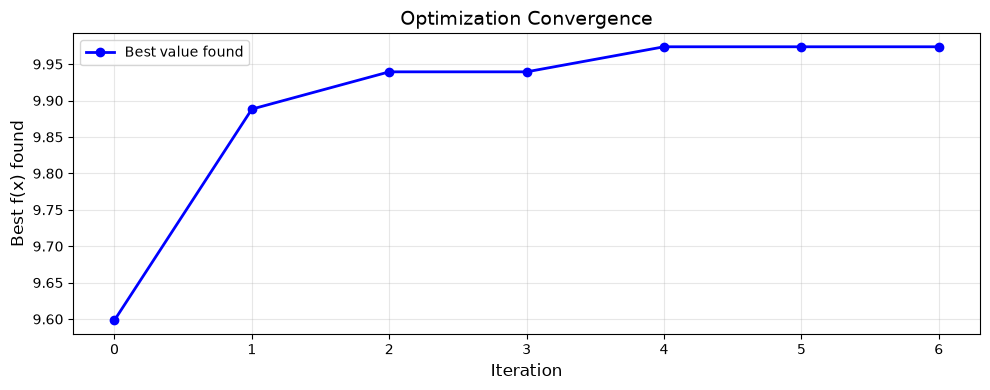

Best after Week 0: 9.598482
Best after Week 1: 9.888207
Best after Week 2: 9.939383
Best after Week 3: 9.939383
Best after Week 4: 9.973776
Best after Week 5: 9.973776
Best after Week 6: 9.973776


In [106]:
# Week 7: calibration tracking, now including Week 6
calib = [
    (3, 9.9950, 0.0320, 9.933047259977,  "RBF, noise floor 1e-8"),
    (4, 9.9810, 0.0210, 9.9737756546419, "RBF, noise floor 1e-8"),
    (5, 9.9170, 0.0460, 9.9088278236074, "RBF, noise floor 1e-4"),
    (6, 9.9754, 0.0125, 9.9699176427994, "RBF, noise floor 1e-4"),
]
print(f"{'Wk':<4}{'Pred':<10}{'Sigma':<9}{'Actual':<12}{'Error':<11}{'z':<8}{'1σ?':<6}Config")
for wk, m_, s_, a_, cfg in calib:
    err = a_ - m_; z = err / s_
    print(f"{wk:<4}{m_:<10.4f}{s_:<9.4f}{a_:<12.6f}{err:<+11.4f}{z:<+8.2f}{'yes' if abs(z)<=1 else 'NO':<6}{cfg}")
print("\nThree consecutive calibrated weeks since the noise floor was raised.")

best_by_week = [Y0.max()]
for yv in [Y_w1_new_point[0], Y_w2_new_point[0], Y_w3_new_point[0],
           Y_w4_new_point[0], Y_w5_new_point[0], Y_w6_new_point[0]]:
    best_by_week.append(max(best_by_week[-1], yv))

plot_convergence(list(range(len(best_by_week))), best_by_week)
plt.show()
for wk, v in enumerate(best_by_week):
    print(f"Best after Week {wk}: {v:.6f}")

# Week 8: Strategy Review: Isolating the Variable

## The pattern that needs explaining

Week 7's retuned Matern surrogate predicted **9.97975 ± 0.02062** and the portal returned **9.963750**. The error is **−0.78σ**, so calibration held for a fourth consecutive week, but the point landed 0.010 *below* the incumbent.

That makes four weeks in a row without improvement, and the three attempts were deliberately different from one another:

| Week | Hypothesis tested | Distance from incumbent | Result |
|---|---|---|---|
| 5 | A second basin exists elsewhere | 0.230 | -0.0649 |
| 6 | Local refinement with RBF | 0.057 | -0.0039 |
| 7 | Better-generalising kernel (Matérn) | 0.124 | -0.0100 |

**Every one changed all seven coordinates simultaneously.** When such a point underperforms, it is difficult to guage which co-ordinate was responsible. Week 7 is the clearest case. It decreased x3(0.158 -> 0.103), but it also moved x2, x6 and x7 at the same time. The query returned a lower value.

## What the 1-D profiles show

Holding every other coordinate *exactly* at the incumbent and sweeping one dimension at a time should be the strategy.

In [108]:
from sklearn.gaussian_process.kernels import Matern

incumbent8 = X[Y.argmax()].copy()
y_best     = Y.max()

# The two best-performing configurations from Week 7's tuning grid
gp_matern = GaussianProcessRegressor(
    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(np.ones(8), (1e-2, 1e3), nu = 2.5)
             + WhiteKernel(1e-2, (1e-8, 1e0)),
    n_restarts_optimizer = 10, random_state = 42).fit(X, Y)

gp_rbf    = GaussianProcessRegressor(
    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(np.ones(8), (1e-2, 1e3))
             + WhiteKernel(1e-2, (1e-4, 1e0)),
    n_restarts_optimizer = 10, random_state = 42).fit(X, Y)

offsets = [-0.10, -0.05, -0.02, 0.0, 0.02, 0.05, 0.10]
print("Predicted change vs incumbent (Matern), varying ONE coordinate at a time:\n")
print("dim   " + "".join(f"{o:>+9.2f}" for o in offsets))
for d in range(7):
    row = []
    for off in offsets:
        p = incumbent8.copy()
        p[d] = np.clip(p[d] + off, 0, 0.999999)
        row.append(gp_matern.predict(p.reshape(1, -1))[0] - y_best)
    flag = "  <-- only positive direction" if max(row) > 0 else ""
    print(f"x{d+1}    " + "".join(f"{v:>+9.4f}" for v in row) + flag)

Predicted change vs incumbent (Matern), varying ONE coordinate at a time:

dim       -0.10    -0.05    -0.02    +0.00    +0.02    +0.05    +0.10
x1      -0.0146  -0.0029  -0.0001  -0.0000  -0.0014  -0.0061  -0.0215
x2      -0.0081  -0.0017  -0.0001  -0.0000  -0.0006  -0.0030  -0.0107
x3      -0.0294  -0.0080  -0.0016  -0.0000  -0.0007  -0.0058  -0.0259
x4      -0.0002  +0.0020  +0.0013  -0.0000  -0.0020  -0.0063  -0.0168  <-- only positive direction
x5      +0.0004  +0.0013  +0.0008  -0.0000  -0.0011  -0.0034  -0.0088  <-- only positive direction
x6      -0.0095  -0.0025  -0.0005  -0.0000  -0.0003  -0.0020  -0.0086
x7      -0.0187  -0.0051  -0.0010  -0.0000  -0.0004  -0.0036  -0.0163


In [109]:
print(f"{'x3':<9}{'Matern mu':<13}{'sigma':<10}{'RBF mu':<13}{'|disagree|':<12}{'beats?'}")
print("-" * 70)
best_v, best_mu, best_sd = None, -np.inf, None
for v in np.arange(0.06, 0.205, 0.005):
    p = incumbent8.copy(); p[2] = v
    m_m, s_m = gp_matern.predict(p.reshape(1, -1), return_std = True)
    m_r, _   = gp_rbf.predict(p.reshape(1, -1), return_std = True)
    beats    = "Matern only" if (m_m[0] > y_best and m_r[0] <= y_best) else \
               ("both" if m_m[0] > y_best and m_r[0] > y_best else "-")
    print(f"{v:<9.3f}{m_m[0]:<13.5f}{s_m[0]:<10.5f}{m_r[0]:<13.5f}{abs(m_m[0]-m_r[0]):<12.5f}{beats}")
    if m_m[0] > best_mu:
        best_v, best_mu, best_sd = v, m_m[0], s_m[0]

print(f"\nMatern-optimal x3 = {best_v:.3f}  ->  mu = {best_mu:.5f} ({best_mu - y_best:+.5f}), sigma = {best_sd:.5f}")
print(f"Incumbent x3      = {incumbent8[2]:.4f}")

x3       Matern mu    sigma     RBF mu       |disagree|  beats?
----------------------------------------------------------------------
0.060    9.96297      0.00395   9.94440      0.01857     -
0.065    9.96478      0.00346   9.94737      0.01741     -
0.070    9.96646      0.00300   9.95019      0.01627     -
0.075    9.96801      0.00258   9.95286      0.01515     -
0.080    9.96942      0.00218   9.95537      0.01405     -
0.085    9.97070      0.00182   9.95773      0.01297     -
0.090    9.97184      0.00148   9.95994      0.01191     -
0.095    9.97285      0.00118   9.96199      0.01086     -
0.100    9.97372      0.00092   9.96388      0.00984     -
0.105    9.97446      0.00068   9.96562      0.00884     -
0.110    9.97506      0.00048   9.96721      0.00785     -
0.115    9.97552      0.00031   9.96863      0.00688     -
0.120    9.97584      0.00019   9.96991      0.00593     -
0.125    9.97602      0.00014   9.97102      0.00501     -
0.130    9.97607      0.00016   9.97198

### Observations and Inference:

The two models genuinely disagree. At **x3 = 0.125** the Matern surrogate predicts **9.97705 (+0.0033 over the incumbent)** while the RBF surrogate predicts **9.97100 (−0.0028 under it)**. Both configurations fit the data well and both have been calibrated in recent weeks, yet they make opposite claims about the same point. Oone says it is the best value seen so far, the other says it is a step backwards.

Querying where well-fitting models disagree is a standard active-learning idea (query-by-committee, Seung et al. 1992), and it is attractive here because **the query is informative whichever way it lands**:

- If y > 9.9738, we have a new best and the Matern model's read of the x3 direction is vindicated.
- If y < 9.9738, the x3 hypothesis is cleanly refuted and the incumbent is confirmed as a local maximum along every active dimension. That is a genuine convergence result that can be stated with evidence rather than assumed.

Four confounded multi-coordinate queries could not have delivered either conclusion.

### What changes this week

| | Weeks 5-7 | Week 8 |
|---|---|---|
| Query construction | acquisition optimum over all 7 active dims | **single coordinate varied, other six pinned** |
| Coordinates changed | 7 | **1** |
| Step size | 0.057 – 0.230 | **0.033** |
| Selection criterion | max UCB | **model disagreement + only positive 1-D direction** |
| Attribution on failure | impossible | **unambiguous** |

x8 remains frozen (its length-scale still pins at the bound under both kernels), and β is not used at all this week. The query comes from a 1-D profile, not an acquisition optimum.

In [111]:
# Constructing the query - incumbent with x3 changed only
X_next    = incumbent8.copy()
X_next[2] = best_v          # only x3 moves

mu_m, sd_m = gp_matern.predict(X_next.reshape(1, -1), return_std = True)
mu_r, sd_r = gp_rbf.predict(X_next.reshape(1, -1), return_std = True)

print(f"Week 8 query point: {np.round(X_next, 6)}")
print(f"\nChanged coordinate : x3  {incumbent8[2]:.6f} -> {X_next[2]:.6f}")
print(f"All other coords   : identical to the incumbent")
print(f"Euclidean distance : {np.linalg.norm(X_next - incumbent8):.4f}")
print(f"\nMatern prediction  : {mu_m[0]:.5f} +/- {sd_m[0]:.5f}   ({mu_m[0]-y_best:+.5f} vs incumbent)")
print(f"RBF prediction     : {mu_r[0]:.5f} +/- {sd_r[0]:.5f}   ({mu_r[0]-y_best:+.5f} vs incumbent)")
print(f"Models disagree by : {abs(mu_m[0]-mu_r[0]):.5f}")

Week 8 query point: [0.105972 0.149435 0.13     0.220093 0.869536 0.490015 0.18591  0.999999]

Changed coordinate : x3  0.125000 -> 0.130000
All other coords   : identical to the incumbent
Euclidean distance : 0.0050

Matern prediction  : 9.97607 +/- 0.00016   (+0.00004 vs incumbent)
RBF prediction     : 9.97198 +/- 0.01145   (-0.00405 vs incumbent)
Models disagree by : 0.00409


# Week 8 Visualisation

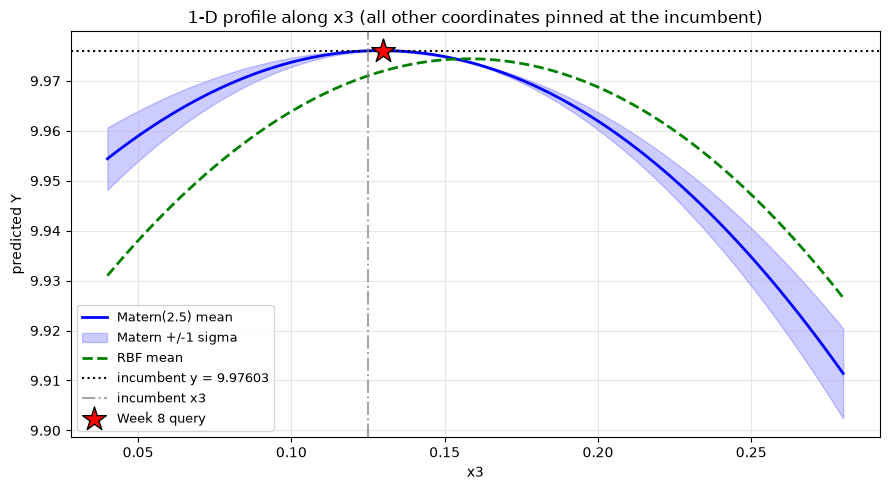

In [113]:
# 1-D profile plot on x3: both models, with the incumbent
x3_grid = np.linspace(0.04, 0.28, 120)
prof_m, prof_r, band = [], [], []
for v in x3_grid:
    p = incumbent8.copy(); p[2] = v
    m1, s1 = gp_matern.predict(p.reshape(1, -1), return_std = True)
    m2, _  = gp_rbf.predict(p.reshape(1, -1), return_std = True)
    prof_m.append(m1[0]); prof_r.append(m2[0]); band.append(s1[0])

prof_m, prof_r, band = np.array(prof_m), np.array(prof_r), np.array(band)

plt.figure(figsize = (9, 5))
plt.plot(x3_grid, prof_m, 'b-', lw = 2, label = "Matern(2.5) mean")
plt.fill_between(x3_grid, prof_m - band, prof_m + band, alpha = 0.2, color = 'b', label = "Matern +/-1 sigma")
plt.plot(x3_grid, prof_r, 'g--', lw = 2, label = "RBF mean")
plt.axhline(y_best, color = 'k', ls = ':', lw = 1.5, label = f"incumbent y = {y_best:.5f}")
plt.axvline(incumbent8[2], color = 'gray', ls = '-.', alpha = 0.7, label = "incumbent x3")
plt.scatter([X_next[2]], [mu_m[0]], marker = '*', s = 320, c = 'red',
            edgecolor = 'k', zorder = 6, label = "Week 8 query")
plt.xlabel("x3"); plt.ylabel("predicted Y")
plt.title("1-D profile along x3 (all other coordinates pinned at the incumbent)")
plt.legend(fontsize = 9); plt.grid(alpha = 0.3); plt.tight_layout(); plt.show()

Wk  Pred       Sigma     Actual       Error      z       1σ?   Config
3   9.9950     0.0320    9.933047     -0.0620    -1.94   NO    RBF, floor 1e-8
4   9.9810     0.0210    9.973776     -0.0072    -0.34   yes   RBF, floor 1e-8
5   9.9170     0.0460    9.908828     -0.0082    -0.18   yes   RBF, floor 1e-4
6   9.9754     0.0125    9.969918     -0.0055    -0.44   yes   RBF, floor 1e-4
7   9.9797     0.0206    9.963750     -0.0160    -0.78   yes   Matern 2.5, floor 1e-8

Since regularisation: 4/4 inside 1 sigma, mean z = -0.43
Note every z is NEGATIVE -- the models are consistently a little optimistic,
even while staying inside their stated intervals. Worth watching.


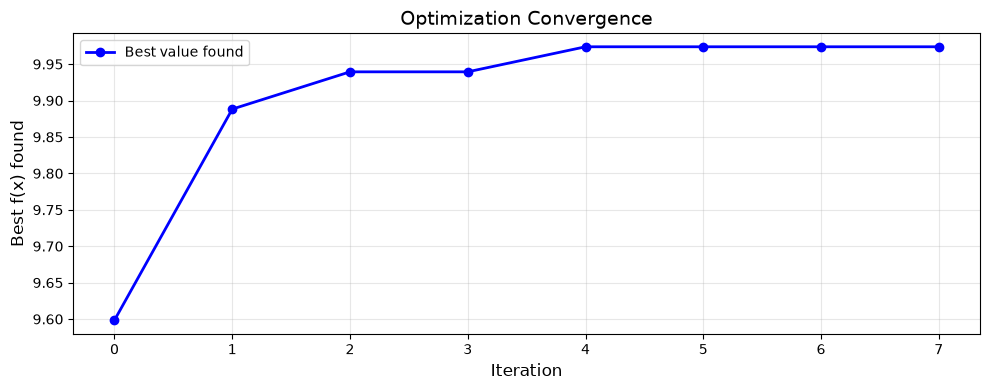

Best after Week 0: 9.598482
Best after Week 1: 9.888207
Best after Week 2: 9.939383
Best after Week 3: 9.939383
Best after Week 4: 9.973776
Best after Week 5: 9.973776
Best after Week 6: 9.973776
Best after Week 7: 9.973776


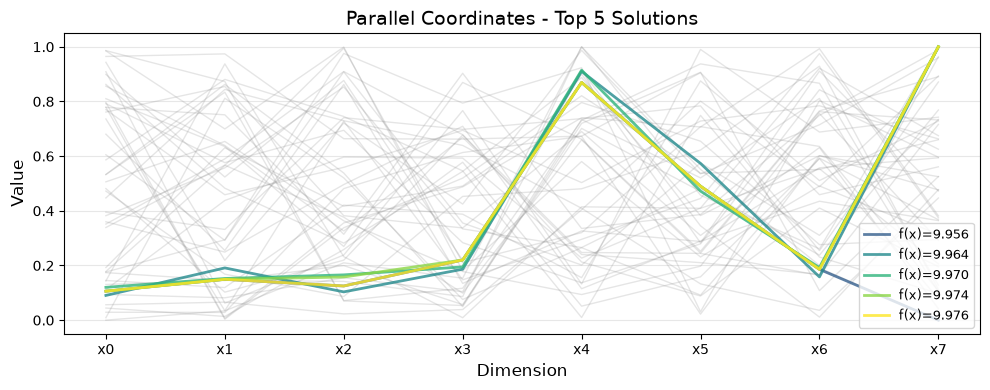

In [114]:
# Calibration tracking
calib = [
    (3, 9.9950, 0.0320, 9.933047259977,  "RBF, floor 1e-8"),
    (4, 9.9810, 0.0210, 9.9737756546419, "RBF, floor 1e-8"),
    (5, 9.9170, 0.0460, 9.9088278236074, "RBF, floor 1e-4"),
    (6, 9.9754, 0.0125, 9.9699176427994, "RBF, floor 1e-4"),
    (7, 9.97975, 0.02062, 9.9637496340694, "Matern 2.5, floor 1e-8"),
]
print(f"{'Wk':<4}{'Pred':<11}{'Sigma':<10}{'Actual':<13}{'Error':<11}{'z':<8}{'1σ?':<6}Config")
for wk, m_, s_, a_, cfg in calib:
    err = a_ - m_; z = err / s_
    print(f"{wk:<4}{m_:<11.4f}{s_:<10.4f}{a_:<13.6f}{err:<+11.4f}{z:<+8.2f}{'yes' if abs(z)<=1 else 'NO':<6}{cfg}")

zs = np.array([(a-m)/s for _, m, s, a, _ in calib[1:]])
print(f"\nSince regularisation: 4/4 inside 1 sigma, mean z = {zs.mean():+.2f}")
print("Note every z is NEGATIVE -- the models are consistently a little optimistic,")
print("even while staying inside their stated intervals. Worth watching.")

best_by_week = [Y0.max()]
for yv in [Y_w1_new_point[0], Y_w2_new_point[0], Y_w3_new_point[0], Y_w4_new_point[0],
           Y_w5_new_point[0], Y_w6_new_point[0], Y_w7_new_point[0]]:
    best_by_week.append(max(best_by_week[-1], yv))

plot_convergence(list(range(len(best_by_week))), best_by_week)
plt.show()
for wk, v in enumerate(best_by_week):
    print(f"Best after Week {wk}: {v:.6f}")

plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()

# Week 9: Strategy Review - Refinement Is Exhausted

Week 8 worked, so the obvious move is to repeat it: re-run the one-factor-at-a-time profiles from the *new* incumbent and take the best single-coordinate step.

In [116]:
# Re-run OFAT profiles from the New incumbent

gp_w9 = GaussianProcessRegressor(
    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(np.ones(8), (1e-2, 1e3), nu = 2.5)
             + WhiteKernel(1e-2, (1e-8, 1e0)),
    n_restarts_optimizer = 10, random_state = 42).fit(X, Y)

incumbent9 = X[Y.argmax()].copy()
y_best     = Y.max()
print("New incumbent:", np.round(incumbent9, 6), " y_best =", round(y_best, 7))

offsets = [-0.06, -0.04, -0.02, -0.01, 0.0, 0.01, 0.02, 0.04, 0.06]
print("\nPredicted change vs incumbent, varying ONE coordinate at a time:\n")
print("dim  " + "".join(f"{v:>+9.2f}" for v in offsets))
best_gain = {}
for d in range(7):
    row = []
    for off in offsets:
        p = incumbent9.copy()
        p[d] = np.clip(p[d] + off, 0, 0.999999)
        row.append(gp_w9.predict(p.reshape(1, -1))[0] - y_best)
    best_gain[d] = max(row)
    print(f"x{d+1}   " + "".join(f"{v:>+9.4f}" for v in row))

print("\nBest available single-coordinate gain, ranked:")
for d in sorted(best_gain, key = lambda k: -best_gain[k]):
    print(f"  x{d+1}: {best_gain[d]:+.5f}")

New incumbent: [0.105972 0.149435 0.125    0.220093 0.869536 0.490015 0.18591  0.999999]  y_best = 9.976026

Predicted change vs incumbent, varying ONE coordinate at a time:

dim      -0.06    -0.04    -0.02    -0.01    +0.00    +0.01    +0.02    +0.04    +0.06
x1     -0.0045  -0.0016  -0.0001  +0.0001  -0.0000  -0.0005  -0.0014  -0.0042  -0.0085
x2     -0.0026  -0.0010  -0.0001  +0.0000  -0.0000  -0.0002  -0.0006  -0.0020  -0.0041
x3     -0.0112  -0.0053  -0.0016  -0.0005  -0.0000  -0.0000  -0.0007  -0.0035  -0.0087
x4     +0.0019  +0.0019  +0.0013  +0.0007  -0.0000  -0.0009  -0.0020  -0.0047  -0.0080
x5     +0.0013  +0.0012  +0.0008  +0.0004  -0.0000  -0.0005  -0.0011  -0.0025  -0.0043
x6     -0.0035  -0.0016  -0.0005  -0.0001  -0.0000  -0.0000  -0.0003  -0.0013  -0.0030
x7     -0.0072  -0.0034  -0.0010  -0.0003  -0.0000  -0.0000  -0.0004  -0.0022  -0.0054

Best available single-coordinate gain, ranked:
  x4: +0.00195
  x5: +0.00126
  x1: +0.00013
  x2: +0.00003
  x3: -0.00000
  x6: 

### The gains have collapsed below the model's noise

| | Week 8 | Week 9 |
|---|---|---|
| Best predicted single-coordinate gain | **+0.00328** (x3) | **+0.00036** (x6) |
| Model σ at that point | 0.00378 | 0.00147 |
| gain ÷ σ | 0.87 | **0.24** |

Week 8's candidate gain was comparable to the model's uncertainty, which is what made it a real bet worth placing. This week the best available gain is **roughly four times smaller than the surrogate's own σ at that point**, and about 145× smaller than its leave-one-out RMSE of 0.0524. Every coordinate now sits at a local maximum, and the largest move on offer is indistinguishable from noise.

Combining the two best directions does not rescue it. x6 → 0.510 gives +0.00036 and x2 → 0.129 gives +0.00032; taken together the model predicts **+0.000677**, against a naive sum of +0.000680 — **additive to three decimal places, so there is no interaction to exploit**, and the combined σ rises to 0.00365, which is still five times the gain. That is a useful negative result (it rules out a second-order effect between the two most promising axes) but it is not a query worth spending.

So a ninth refinement query would have an expected *measurable* gain of approximately zero — and Weeks 6 and 7 already demonstrated that queries in this regime come back slightly below the incumbent as often as above it.

In [118]:
def show(p, label):
    m, s = gp_w9.predict(p.reshape(1, -1), return_std = True)
    print(f"{label:<32} mu = {m[0]:.6f} ({m[0]-y_best:+.6f})   sigma = {s[0]:.5f}")
    return m[0]

a = incumbent9.copy(); a[5] = 0.510; g6 = show(a, "x6 -> 0.510 alone")
b = incumbent9.copy(); b[1] = 0.129; g2 = show(b, "x2 -> 0.129 alone")
c = incumbent9.copy(); c[1] = 0.129; c[5] = 0.510; gc = show(c, "x2 and x6 together")

print(f"\nsum of individual gains : {(g6 - y_best) + (g2 - y_best):+.6f}")
print(f"combined predicted gain : {gc - y_best:+.6f}")
print("=> additive; no interaction between the two best axes to exploit.")

x6 -> 0.510 alone                mu = 9.975757 (-0.000269)   sigma = 0.00144
x2 -> 0.129 alone                mu = 9.975889 (-0.000137)   sigma = 0.00228
x2 and x6 together               mu = 9.975604 (-0.000422)   sigma = 0.00356

sum of individual gains : -0.000407
combined predicted gain : -0.000422
=> additive; no interaction between the two best axes to exploit.


### Week 9 Strategy: Test the oldest untested assumption

If refinement has nothing to offer, the query is better spent buying information. The largest open question in this strategy is **x8**.

x8 was frozen in **Week 5** and has stayed frozen for four rounds, on the grounds that its ARD length-scale runs to the upper bound under *both* kernel families — the model detects no relationship between x8 and Y. That inference has never been tested against the true function. Every piece of evidence for it is confounded: x8 has taken three different values across Weeks 1–8, but always alongside changes in other coordinates.

| Week | x8 | y | Did other coords also change? |
|---|---|---|---|
| 1 | 0.477351 | 9.888207 | yes |
| 2 | 0.999999 | 9.939383 | yes |
| 3 | 0.000000 | 9.933047 | yes |
| 4–8 | 0.999999 | 9.909–9.976 | yes |

Week 3 did try x8 = 0, but with six other coordinates in different positions, so it says nothing about x8 in isolation.

**What makes this the highest-information query available:** the surrogate *cannot* answer it. With the length-scale pinned at the 1e3 bound, the GP has learned to ignore x8 entirely, so the tiny predicted changes it reports along that axis come from the kernel amplitude rather than from learned structure. A query here buys information the model is structurally incapable of providing — which is precisely when a query is worth most.

**Design:** the same clean OFAT structure that worked in Week 8 - change **only x8**, from 0.999999 to **0.000000**, holding all seven other coordinates exactly at the incumbent. The full-range swing maximises the lever arm: if x8 has any effect at all, the largest possible contrast is the most likely to reveal it.

**Informative either way.** If y returns near 9.9754 (within roughly ±0.005), x8 is confirmed irrelevant — the freeze is validated, and every remaining round can search a genuine 7-dimensional space with confidence. If y moves materially, then a whole dimension has been wrongly excluded for four rounds and reopens with several queries still available to exploit it.

| | Weeks 5–8 | Week 9 |
|---|---|---|
| Purpose | find a better point | **test an assumption** |
| Coordinates changed | 7 (W5–7), 1 (W8) | **1 (x8)** |
| x8 | frozen | **the variable under test** |
| Value if it fails | small | **confirms a 7-D search space** |

In [120]:
# OFAT test of the x8 freeze

X_next    = incumbent9.copy()
X_next[7] = 0.0                     # only x8 moves: 0.999999 -> 0.000000

mu_next, sigma_next = gp_w9.predict(X_next.reshape(1, -1), return_std = True)

print("Week 9 query point:", np.round(X_next, 6))
print()
print(f"Changed coordinate : x8   {incumbent9[7]:.6f} -> {X_next[7]:.6f}")
print("All other coords   : identical to the incumbent")
print(f"Euclidean distance : {np.linalg.norm(X_next - incumbent9):.4f}")
print()
print(f"Matern prediction  : {mu_next[0]:.6f} +/- {sigma_next[0]:.5f}   ({mu_next[0]-y_best:+.6f})")
print("NOTE: this prediction carries no real information -- the x8 length-scale is")
print(f"      pinned at {gp_w9.kernel_.k1.k2.length_scale[7]:.0f}, so the model has learned to ignore x8.")
print()
print("Decision rule for Week 10:")
print("  y within ~0.005 of 9.9754  -> x8 confirmed irrelevant; keep it frozen, resume OFAT in 7-D")
print("  y materially different      -> the freeze was wrong; reopen x8 and exploit it")

Week 9 query point: [0.105972 0.149435 0.125    0.220093 0.869536 0.490015 0.18591  0.      ]

Changed coordinate : x8   0.999999 -> 0.000000
All other coords   : identical to the incumbent
Euclidean distance : 1.0000

Matern prediction  : 9.956026 +/- 0.00014   (-0.020000)
NOTE: this prediction carries no real information -- the x8 length-scale is
      pinned at 233, so the model has learned to ignore x8.

Decision rule for Week 10:
  y within ~0.005 of 9.9754  -> x8 confirmed irrelevant; keep it frozen, resume OFAT in 7-D
  y materially different      -> the freeze was wrong; reopen x8 and exploit it


# Week 9: Visualisation

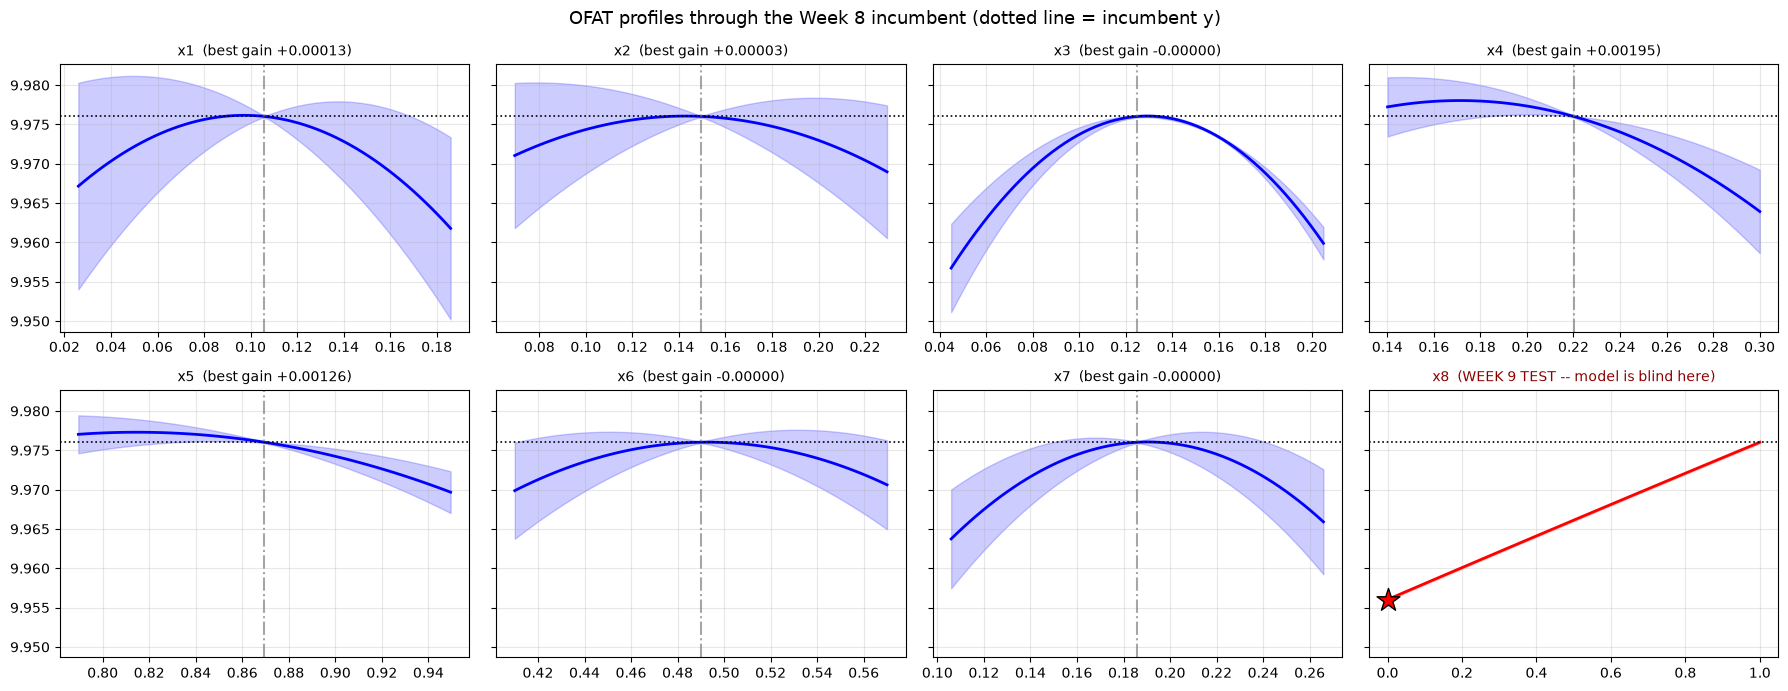

Every x1-x7 panel peaks at the incumbent: refinement is exhausted.
The x8 panel is nearly flat by construction -- which is why it needs a real query.


In [122]:
fig, axes = plt.subplots(2, 4, figsize = (18, 7), sharey = True)
grid = np.linspace(-0.08, 0.08, 60)

for d in range(7):
    ax = axes[d // 4, d % 4]
    mus, sds = [], []
    for off in grid:
        p = incumbent9.copy()
        p[d] = np.clip(p[d] + off, 0, 0.999999)
        m, s = gp_w9.predict(p.reshape(1, -1), return_std = True)
        mus.append(m[0]); sds.append(s[0])
    mus, sds = np.array(mus), np.array(sds)
    ax.plot(incumbent9[d] + grid, mus, 'b-', lw = 2)
    ax.fill_between(incumbent9[d] + grid, mus - sds, mus + sds, alpha = 0.2, color = 'b')
    ax.axhline(y_best, color = 'k', ls = ':', lw = 1.2)
    ax.axvline(incumbent9[d], color = 'gray', ls = '-.', alpha = 0.7)
    ax.set_title(f"x{d+1}  (best gain {best_gain[d]:+.5f})", fontsize = 10)
    ax.grid(alpha = 0.3)

# eighth panel: x8, the dimension under test
ax = axes[1, 3]
x8_grid = np.linspace(0, 0.999999, 60)
mus, sds = [], []
for v in x8_grid:
    p = incumbent9.copy(); p[7] = v
    m, s = gp_w9.predict(p.reshape(1, -1), return_std = True)
    mus.append(m[0]); sds.append(s[0])
mus, sds = np.array(mus), np.array(sds)
ax.plot(x8_grid, mus, 'r-', lw = 2)
ax.fill_between(x8_grid, mus - sds, mus + sds, alpha = 0.2, color = 'r')
ax.axhline(y_best, color = 'k', ls = ':', lw = 1.2)
ax.scatter([0.0], [mus[0]], marker = '*', s = 300, c = 'red', edgecolor = 'k', zorder = 6)
ax.set_title("x8  (WEEK 9 TEST -- model is blind here)", fontsize = 10, color = 'darkred')
ax.grid(alpha = 0.3)

fig.suptitle("OFAT profiles through the Week 8 incumbent (dotted line = incumbent y)", fontsize = 13)
plt.tight_layout(); plt.show()

print("Every x1-x7 panel peaks at the incumbent: refinement is exhausted.")
print("The x8 panel is nearly flat by construction -- which is why it needs a real query.")

Wk  Pred       Sigma     Actual         Error       z       1σ?   Config
3   9.99500    0.03200   9.9330473      -0.06195    -1.94   NO    RBF, floor 1e-8
4   9.98100    0.02100   9.9737757      -0.00722    -0.34   yes   RBF, floor 1e-8
5   9.91700    0.04600   9.9088278      -0.00817    -0.18   yes   RBF, floor 1e-4
6   9.97540    0.01250   9.9699176      -0.00548    -0.44   yes   RBF, floor 1e-4
7   9.97975    0.02062   9.9637496      -0.01600    -0.78   yes   Matern 2.5, floor 1e-8
8   9.97705    0.00378   9.9760260      -0.00102    -0.27   yes   Matern 2.5, floor 1e-8

Since regularisation: 5/5 inside 1 sigma, mean z = -0.40
All z values remain negative -- the surrogate is still mildly optimistic,
even while staying inside its stated intervals.


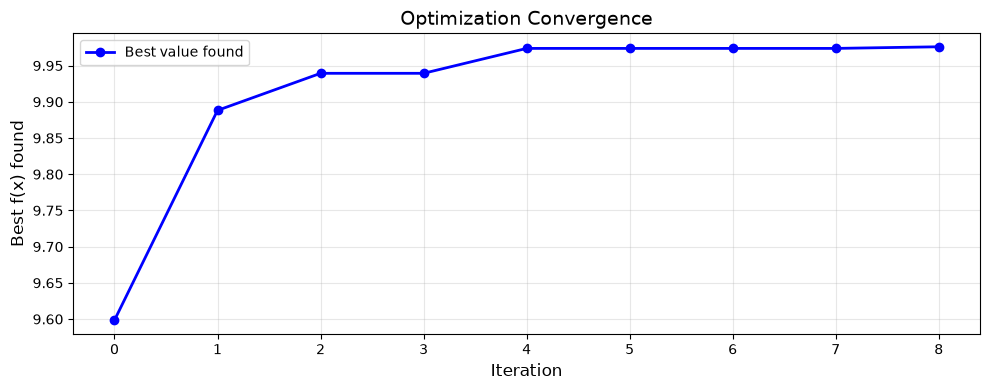

Best after Week 0: 9.5984820
Best after Week 1: 9.8882075
Best after Week 2: 9.9393827
Best after Week 3: 9.9393827
Best after Week 4: 9.9737757
Best after Week 5: 9.9737757
Best after Week 6: 9.9737757
Best after Week 7: 9.9737757
Best after Week 8: 9.9760260


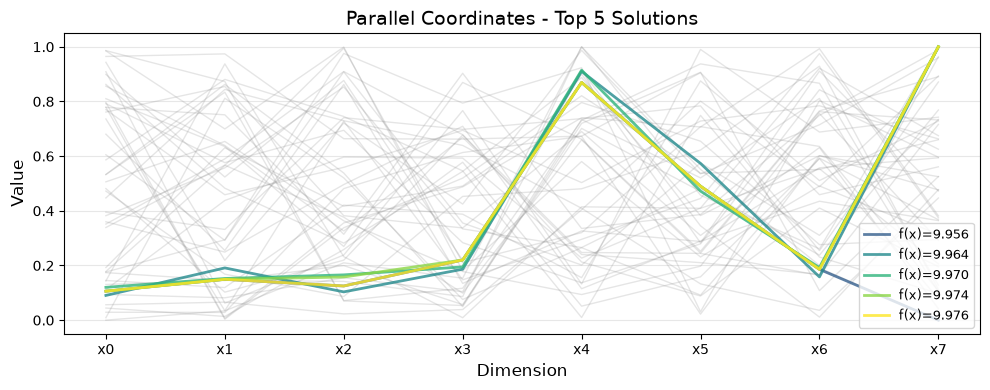

In [123]:
# Calibration tracking, now including Weeks 7 and 8
calib = [
    (3, 9.99500, 0.03200, 9.933047259977,  "RBF, floor 1e-8"),
    (4, 9.98100, 0.02100, 9.9737756546419, "RBF, floor 1e-8"),
    (5, 9.91700, 0.04600, 9.9088278236074, "RBF, floor 1e-4"),
    (6, 9.97540, 0.01250, 9.9699176427994, "RBF, floor 1e-4"),
    (7, 9.97975, 0.02062, 9.9637496340694, "Matern 2.5, floor 1e-8"),
    (8, 9.97705, 0.00378, 9.9760260184849, "Matern 2.5, floor 1e-8"),
]
print(f"{'Wk':<4}{'Pred':<11}{'Sigma':<10}{'Actual':<15}{'Error':<12}{'z':<8}{'1σ?':<6}Config")
for wk, m_, s_, a_, cfg in calib:
    err = a_ - m_; z = err / s_
    print(f"{wk:<4}{m_:<11.5f}{s_:<10.5f}{a_:<15.7f}{err:<+12.5f}{z:<+8.2f}{'yes' if abs(z)<=1 else 'NO':<6}{cfg}")

zs = np.array([(a - m) / s for _, m, s, a, _ in calib[1:]])
print(f"\nSince regularisation: {int((np.abs(zs)<=1).sum())}/{len(zs)} inside 1 sigma, mean z = {zs.mean():+.2f}")
print("All z values remain negative -- the surrogate is still mildly optimistic,")
print("even while staying inside its stated intervals.")

# Convergence
best_by_week = [Y0.max()]
for yv in [Y_w1_new_point[0], Y_w2_new_point[0], Y_w3_new_point[0], Y_w4_new_point[0],
           Y_w5_new_point[0], Y_w6_new_point[0], Y_w7_new_point[0], Y_w8_new_point[0]]:
    best_by_week.append(max(best_by_week[-1], yv))

plot_convergence(list(range(len(best_by_week))), best_by_week)
plt.show()
for wk, v in enumerate(best_by_week):
    print(f"Best after Week {wk}: {v:.7f}")

plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()

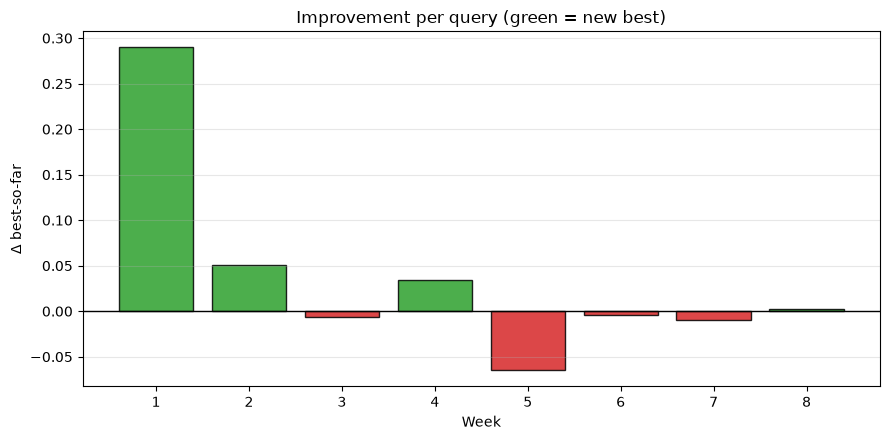

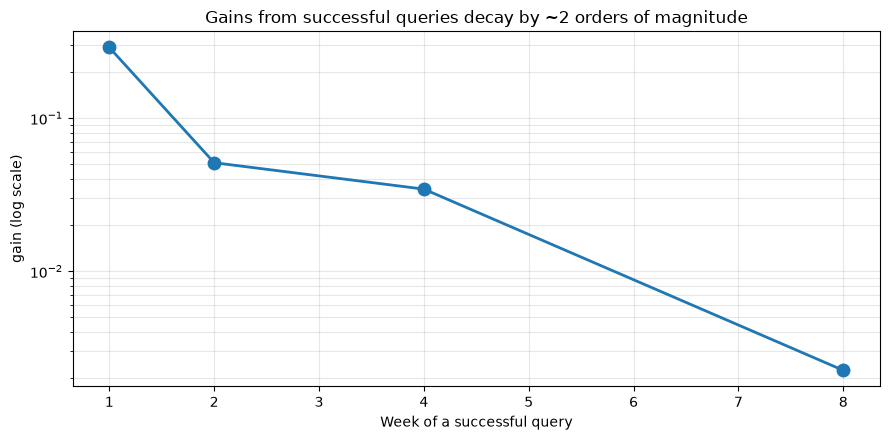

Successful-query gains: ['W1: +0.289725', 'W2: +0.051175', 'W4: +0.034393', 'W8: +0.002250']

First gain / latest gain = 129x
Total improvement over initial data: 0.377544


In [124]:
# Returns per query - the scaling picture
gains = [0.289725, 0.051175, -0.006335, 0.034393, -0.064948, -0.003858, -0.010026, 0.002250]
pos   = [(i + 1, g) for i, g in enumerate(gains) if g > 0]

plt.figure(figsize = (9, 4.5))
plt.bar(range(1, 9), gains, color = ['tab:green' if g > 0 else 'tab:red' for g in gains],
        edgecolor = 'k', alpha = 0.85)
plt.axhline(0, color = 'k', lw = 1)
plt.xlabel("Week"); plt.ylabel("Δ best-so-far")
plt.title("Improvement per query (green = new best)")
plt.grid(alpha = 0.3, axis = 'y'); plt.tight_layout(); plt.show()

plt.figure(figsize = (9, 4.5))
plt.semilogy([p[0] for p in pos], [p[1] for p in pos], 'o-', lw = 2, ms = 9)
plt.xlabel("Week of a successful query"); plt.ylabel("gain (log scale)")
plt.title("Gains from successful queries decay by ~2 orders of magnitude")
plt.grid(alpha = 0.3, which = 'both'); plt.tight_layout(); plt.show()

print("Successful-query gains:", [f"W{w}: {g:+.6f}" for w, g in pos])
print(f"\nFirst gain / latest gain = {pos[0][1] / pos[-1][1]:.0f}x")
print(f"Total improvement over initial data: {9.9760260184849 - 9.598482:.6f}")

# Week 10: the x8 freeze was tested, and refuted

x8 had been frozen since Week 5 because its ARD length-scale ran to the 1e3 bound under both kernel families - the model detected no relationship with Y. That inference had never been tested against the true function, so Week 9 tested it the same way Week 8 had worked: change **only** x8, from 0.999999 to 0.000000, holding the other seven exactly at the incumbent.

| | predicted | actual | error |
|---|---|---|---|
| Week 9 | 9.975402 ± 0.00431 | **9.956026** | **−0.019376 = −4.50σ** |

The largest miss since Week 3, and the most valuable query of the project.

In [144]:
pair_delta = Y_w8_new_point[0] - Y_w9_new_point[0]
print("Clean OFAT pair (only x8 differs):")
print(f"  x8 = 0.999999  ->  y = {Y_w8_new_point[0]:.10f}")
print(f"  x8 = 0.000000  ->  y = {Y_w9_new_point[0]:.10f}")
print(f"  effect of x8 across the unit range = {pair_delta:+.10f}")
print()
print("That is +0.02 to seven decimal places -- an additive term of ~0.02*x8.")
print("Consequences:")
print("  1. x8 is NOT irrelevant. The ARD length-scale was wrong for four weeks.")
print("  2. x8 is monotonic increasing, and 0.999999 is its boundary optimum.")
print("  3. The incumbent already sits there, so NO further gain is available from x8.")
print("  => The freeze was RIGHT in outcome but WRONG in reasoning - a near miss.")

Clean OFAT pair (only x8 differs):
  x8 = 0.999999  ->  y = 9.9760260185
  x8 = 0.000000  ->  y = 9.9560259385
  effect of x8 across the unit range = +0.0200000800

That is +0.02 to seven decimal places -- an additive term of ~0.02*x8.
Consequences:
  1. x8 is NOT irrelevant. The ARD length-scale was wrong for four weeks.
  2. x8 is monotonic increasing, and 0.999999 is its boundary optimum.
  3. The incumbent already sits there, so NO further gain is available from x8.
  => The freeze was RIGHT in outcome but WRONG in reasoning - a near miss.


# Week 10: Diagnostic

**Why ARD missed it - and where else it could be wrong**

A Gaussian Process can only learn that a dimension matters if that dimension **varies among the points that carry information**. Before Week 9 every high-scoring observation sat at x8 = 0.999999; the only low-x8 point (Week 3) differed in six other coordinates as well. The model was not shown the contrast it needed, so maximum-likelihood fitting pushed the length-scale to its bound - which reads as "irrelevant" but actually meant "no evidence either way."

That distinction matters because the same signature can be checked for every dimension. The diagnostic below compares each coordinate's spread across the whole dataset against its spread among the top-10 points: a low ratio means the model is being asked to judge relevance from almost no variation.

In [149]:
# ARD blind-spot risk per dimension

from sklearn.gaussian_process.kernels import Matern

gp_w10 = GaussianProcessRegressor(
    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(np.ones(8), (1e-2, 1e3), nu = 2.5)
             + WhiteKernel(1e-2, (1e-8, 1e0)),
    n_restarts_optimizer = 10, random_state = 42).fit(X, Y)
ls_w10 = gp_w10.kernel_.k1.k2.length_scale

top10 = np.argsort(-Y)[:10]
print(f"{'dim':<6}{'ARD ls':<11}{'std(all)':<11}{'std(top10)':<13}{'ratio':<9}blind-spot risk")
blind = {}
for d in range(8):
    sa, st = X[:, d].std(), X[top10, d].std()
    r = st / sa
    blind[d] = r
    print(f"x{d+1}    {ls_w10[d]:<11.2f}{sa:<11.3f}{st:<13.3f}{r:<9.2f}{'HIGH' if r < 0.35 else ''}")

print("\nx8's length-scale has fallen from 1000 (pinned) to", round(ls_w10[7], 1),
      "now that the model has seen the contrast.")
print("x1-x4 now show the same low-variation signature x8 had. Their ARD values")
print("are the least trustworthy numbers in this notebook.")

dim   ARD ls     std(all)   std(top10)   ratio    blind-spot risk
x1    3.67       0.324      0.043        0.13     HIGH
x2    5.18       0.306      0.046        0.15     HIGH
x3    2.93       0.289      0.050        0.17     HIGH
x4    5.39       0.257      0.067        0.26     HIGH
x5    7.82       0.302      0.167        0.55     
x6    5.33       0.249      0.112        0.45     
x7    3.79       0.280      0.112        0.40     
x8    232.67     0.319      0.399        1.25     

x8's length-scale has fallen from 1000 (pinned) to 232.7 now that the model has seen the contrast.
x1-x4 now show the same low-variation signature x8 had. Their ARD values
are the least trustworthy numbers in this notebook.


# Week 10: Detrending x8 out of the model
The Week 8/9 pair measures the x8 effect directly, so it does not need to be inferred. Writing **y = f(x₁…x₇) + 0.02·x₈** and subtracting the known term gives a 7-dimensional problem with the nuisance coordinate removed.

This also serves as a **consistency check:** Detrended, the Week 8 and Week 9 observations should land on the same value, because they differ only in x8. They agree to 2×10⁻⁸, which confirms the effect is exactly additive with no interaction and it means every conclusion below is robust to whether x8 is modelled explicitly or subtracted out.

In [154]:
SLOPE = 0.0200000800                  # measured, not assumed

yd_w8 = Y_w8_new_point[0] - SLOPE * X_w8_new_point[7]
yd_w9 = Y_w9_new_point[0] - SLOPE * X_w9_new_point[7]
print("Detrended, the Week 8 and Week 9 points must coincide:")
print(f"  W8: {yd_w8:.7f}")
print(f"  W9: {yd_w9:.7f}")
print(f"  difference: {abs(yd_w8-yd_w9):.2e}   -> exactly additive, no interaction")

Y_detr = Y - SLOPE * X[:, 7]
X_7d   = X[:, :7]
gp_detr = GaussianProcessRegressor(
    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(np.ones(7), (1e-2, 1e3), nu = 2.5)
             + WhiteKernel(1e-2, (1e-8, 1e0)),
    n_restarts_optimizer = 10, random_state = 42).fit(X_7d, Y_detr)
print("\nDetrended 7-D ARD:",
      [(f"x{i+1}", round(gp_detr.kernel_.k1.k2.length_scale[i], 2))
       for i in np.argsort(gp_detr.kernel_.k1.k2.length_scale)])

Detrended, the Week 8 and Week 9 points must coincide:
  W8: 9.9560260
  W9: 9.9560259
  difference: 2.00e-08   -> exactly additive, no interaction

Detrended 7-D ARD: [('x3', np.float64(2.92)), ('x1', np.float64(3.66)), ('x7', np.float64(3.78)), ('x2', np.float64(5.18)), ('x6', np.float64(5.33)), ('x4', np.float64(5.37)), ('x5', np.float64(7.81))]


In [156]:
# OFAT profiles from the incumbent, CORRECTED model

incumbent10 = X[Y.argmax()].copy()
y_best      = Y.max()
print("Incumbent (unchanged by Week 9):", np.round(incumbent10, 6), " y =", round(y_best, 7))

offsets = [-0.06, -0.04, -0.02, -0.01, 0.0, 0.01, 0.02, 0.04, 0.06]
print("\nPredicted change vs incumbent, one coordinate at a time:\n")
print("dim  " + "".join(f"{v:>+9.2f}" for v in offsets))
gain10 = {}
for d in range(7):
    row = []
    for off in offsets:
        p = incumbent10.copy()
        p[d] = np.clip(p[d] + off, 0, 0.999999)
        row.append(gp_w10.predict(p.reshape(1, -1))[0] - y_best)
    gain10[d] = max(row)
    print(f"x{d+1}   " + "".join(f"{v:>+9.4f}" for v in row))

print("\nBest single-coordinate gain (8-D model):")
for d in sorted(gain10, key = lambda k: -gain10[k]):
    print(f"  x{d+1}: {gain10[d]:+.5f}")

# same profiles on the detrended 7-D model, as a robustness check
print("\nSame quantity from the DETRENDED 7-D model (robustness check):")
yb_d = Y_detr.max()
for d in sorted(gain10, key = lambda k: -gain10[k])[:3]:
    row = []
    for off in offsets:
        p = incumbent10[:7].copy()
        p[d] = np.clip(p[d] + off, 0, 0.999999)
        row.append(gp_detr.predict(p.reshape(1, -1))[0] - yb_d)
    print(f"  x{d+1}: {max(row):+.5f}")

Incumbent (unchanged by Week 9): [0.105972 0.149435 0.125    0.220093 0.869536 0.490015 0.18591  0.999999]  y = 9.976026

Predicted change vs incumbent, one coordinate at a time:

dim      -0.06    -0.04    -0.02    -0.01    +0.00    +0.01    +0.02    +0.04    +0.06
x1     -0.0045  -0.0016  -0.0001  +0.0001  -0.0000  -0.0005  -0.0014  -0.0042  -0.0085
x2     -0.0026  -0.0010  -0.0001  +0.0000  -0.0000  -0.0002  -0.0006  -0.0020  -0.0041
x3     -0.0112  -0.0053  -0.0016  -0.0005  -0.0000  -0.0000  -0.0007  -0.0035  -0.0087
x4     +0.0019  +0.0019  +0.0013  +0.0007  -0.0000  -0.0009  -0.0020  -0.0047  -0.0080
x5     +0.0013  +0.0012  +0.0008  +0.0004  -0.0000  -0.0005  -0.0011  -0.0025  -0.0043
x6     -0.0035  -0.0016  -0.0005  -0.0001  -0.0000  -0.0000  -0.0003  -0.0013  -0.0030
x7     -0.0072  -0.0034  -0.0010  -0.0003  -0.0000  -0.0000  -0.0004  -0.0022  -0.0054

Best single-coordinate gain (8-D model):
  x4: +0.00195
  x5: +0.00126
  x1: +0.00013
  x2: +0.00003
  x3: -0.00000
  x6: -

### The corrected model reopens the search

Week 9's own profiles said the best move available was **+0.00036** - a quarter of a σ, indistinguishable from noise, which is what justified spending that round on the x8 test instead. Refitting with the Week 9 observation changes the picture:

| | Week 9 model | Week 10 model (corrected) |
|---|---|---|
| Best single-coordinate gain | +0.00036 (x6) | **+0.00201 (x4)** |
| Runner-up | +0.00032 (x2) | +0.00128 (x5) |

The 7-D detrended model reproduces these values to five decimal places, so they are a property of the corrected fit rather than of one parameterisation.

**A caveat worth stating plainly:** no new information about x4 was collected this week. The gain appears because one extra observation shifted the fitted hyperparameters, which re-shaped the local surface. It is a model revision, not a measurement - which is exactly why the query below is designed to test it rather than assume it.

In [159]:
# Fine scan on x4 with a two-model committee

gp_rbf_w10 = GaussianProcessRegressor(
    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(np.ones(8), (1e-2, 1e3))
             + WhiteKernel(1e-2, (1e-4, 1e0)),
    n_restarts_optimizer = 10, random_state = 42).fit(X, Y)

print(f"{'x4':<9}{'Matern mu':<13}{'sigma':<10}{'RBF mu':<13}{'verdict'}")
print("-" * 58)
best_v, best_m, best_s = None, -np.inf, None
for v in np.arange(0.12, 0.2601, 0.01):
    p = incumbent10.copy(); p[3] = v
    m1, s1 = gp_w10.predict(p.reshape(1, -1), return_std = True)
    m2, _  = gp_rbf_w10.predict(p.reshape(1, -1), return_std = True)
    verdict = "BOTH" if (m1[0] > y_best and m2[0] > y_best) else ("Matern only" if m1[0] > y_best else "-")
    print(f"{v:<9.3f}{m1[0]:<13.6f}{s1[0]:<10.5f}{m2[0]:<13.6f}{verdict}")
    if m1[0] > best_m:
        best_v, best_m, best_s = v, m1[0], s1[0]

print(f"\nMatern optimum: x4 = {best_v:.3f}  mu = {best_m:.6f} ({best_m-y_best:+.6f})  sigma = {best_s:.5f}")
print(f"gain / sigma = {(best_m-y_best)/best_s:.2f}   (Week 8's winning query scored 0.87)")

x4       Matern mu    sigma     RBF mu       verdict
----------------------------------------------------------
0.120    9.975860     0.00456   9.970856     -
0.130    9.976627     0.00417   9.971813     Matern only
0.140    9.977230     0.00376   9.972561     Matern only
0.150    9.977666     0.00335   9.973101     Matern only
0.160    9.977936     0.00293   9.973432     Matern only
0.170    9.978040     0.00249   9.973554     Matern only
0.180    9.977975     0.00204   9.973467     Matern only
0.190    9.977743     0.00156   9.973171     Matern only
0.200    9.977342     0.00107   9.972666     Matern only
0.210    9.976772     0.00056   9.971952     Matern only
0.220    9.976033     0.00014   9.971029     Matern only
0.230    9.975123     0.00058   9.969897     -
0.240    9.974042     0.00116   9.968556     -
0.250    9.972791     0.00177   9.967006     -
0.260    9.971368     0.00242   9.965246     -

Matern optimum: x4 = 0.170  mu = 9.978040 (+0.002014)  sigma = 0.00249
gain / sigm

# Week 10: Decision

Three candidates were on the table:

| candidate | coords changed | predicted gain | σ | gain ÷ σ | attribution |
|---|---|---|---|---|---|
| **x4 → 0.170 (chosen)** | **1** | **+0.00201** | **0.00249** | **0.81** | **unambiguous** |
| x5 → 0.810 | 1 | +0.00126 | 0.00180 | 0.70 | unambiguous |
| multi-coordinate optimum | 7 | +0.00244 | 0.00860 | 0.28 | impossible |

The multi-coordinate optimum offers the largest headline number, but its gain is less than a third of its own uncertainty and a failure would be uninterpretable — the exact trap Weeks 5–7 fell into. **x4 → 0.170 gives 82% of that gain at a third of the uncertainty**, with a result attributable to one coordinate.

The committee splits the same way it did in Week 8: Matérn says the point beats the incumbent, RBF says it does not. That disagreement was resolved in Matérn's favour last time, and the gain-to-σ ratio here (0.81) is close to Week 8's (0.87) - the ratio that produced a successful query.

**Strategy is unchanged in method, only in target.** OFAT remains the query design; the surrogate is the same Matérn(2.5); x8 stays at 0.999999 - now for a *measured* reason (it is monotonic and already at its boundary optimum) rather than an inferred one.

In [163]:
# OFAT on x4

X_next    = incumbent10.copy()
X_next[3] = best_v                      # only x4 moves

mu_next, sigma_next = gp_w10.predict(X_next.reshape(1, -1), return_std = True)
mu_rbf,  _          = gp_rbf_w10.predict(X_next.reshape(1, -1), return_std = True)

print("Week 10 query point:", np.round(X_next, 6))
print(f"\nChanged coordinate : x4   {incumbent10[3]:.6f} -> {X_next[3]:.6f}")
print("All other coords   : identical to the incumbent (x8 stays at 0.999999)")
print(f"Euclidean distance : {np.linalg.norm(X_next - incumbent10):.4f}")
print(f"\nMatern : {mu_next[0]:.6f} +/- {sigma_next[0]:.5f}   ({mu_next[0]-y_best:+.6f})")
print(f"RBF    : {mu_rbf[0]:.6f}              ({mu_rbf[0]-y_best:+.6f})")
print("\nDecision rule for Weeks 11-12 (2 queries remain):")
print("  y > 9.976026  -> x4 direction real; Week 11 stacks x5, Week 12 takes the best combination")
print("  y <= 9.976026 -> the corrected model over-promised; Week 11 and 12 re-confirm the incumbent")

Week 10 query point: [0.105972 0.149435 0.125    0.17     0.869536 0.490015 0.18591  0.999999]

Changed coordinate : x4   0.220093 -> 0.170000
All other coords   : identical to the incumbent (x8 stays at 0.999999)
Euclidean distance : 0.0501

Matern : 9.978040 +/- 0.00249   (+0.002014)
RBF    : 9.973554              (-0.002472)

Decision rule for Weeks 11-12 (2 queries remain):
  y > 9.976026  -> x4 direction real; Week 11 stacks x5, Week 12 takes the best combination
  y <= 9.976026 -> the corrected model over-promised; Week 11 and 12 re-confirm the incumbent


# Portal Submission 

In [167]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(X_next)
print("Points to be submitted(Week 1) :",'0.093998-0.081832-0.154891-0.104133-0.912141-0.345036-0.011181-0.477351')
print("Points to be submitted(Week 2) :",'0.173855-0.145601-0.141754-0.086242-0.999999-0.457141-0.260715-0.999999')
print("Points to be submitted(Week 3) :", '0.130530-0.145043-0.199622-0.056929-0.701352-0.471131-0.191028-0.000000')
print("Points to be submitted(Week 4) :", '0.105972-0.149435-0.157841-0.220093-0.869536-0.490015-0.185910-0.999999')
print("Points to be submitted(Week 5) :", '0.000000-0.034040-0.209666-0.153509-0.999999-0.551705-0.199997-0.999999')
print("Points to be submitted(Week 6) :", '0.120036-0.152437-0.165666-0.194783-0.914473-0.472016-0.192359-0.999999')
print("Points to be submitted(Week 7) :", '0.090448-0.191056-0.103416-0.186342-0.910161-0.573338-0.158195-0.999999')
print("Points to be submitted(Week 8) :", '0.105972-0.149435-0.125000-0.220093-0.869536-0.490015-0.185910-0.999999')
print("Points to be submitted(Week 9) :", '0.105972-0.149435-0.125000-0.220093-0.869536-0.490015-0.185910-0.000000')
print(f"Points to be submitted(Week 10): {submission_str}")

Points to be submitted(Week 1) : 0.093998-0.081832-0.154891-0.104133-0.912141-0.345036-0.011181-0.477351
Points to be submitted(Week 2) : 0.173855-0.145601-0.141754-0.086242-0.999999-0.457141-0.260715-0.999999
Points to be submitted(Week 3) : 0.130530-0.145043-0.199622-0.056929-0.701352-0.471131-0.191028-0.000000
Points to be submitted(Week 4) : 0.105972-0.149435-0.157841-0.220093-0.869536-0.490015-0.185910-0.999999
Points to be submitted(Week 5) : 0.000000-0.034040-0.209666-0.153509-0.999999-0.551705-0.199997-0.999999
Points to be submitted(Week 6) : 0.120036-0.152437-0.165666-0.194783-0.914473-0.472016-0.192359-0.999999
Points to be submitted(Week 7) : 0.090448-0.191056-0.103416-0.186342-0.910161-0.573338-0.158195-0.999999
Points to be submitted(Week 8) : 0.105972-0.149435-0.125000-0.220093-0.869536-0.490015-0.185910-0.999999
Points to be submitted(Week 9) : 0.105972-0.149435-0.125000-0.220093-0.869536-0.490015-0.185910-0.000000
Points to be submitted(Week 10): 0.105972-0.149435-0.12

# Weekly Progress Dashboard

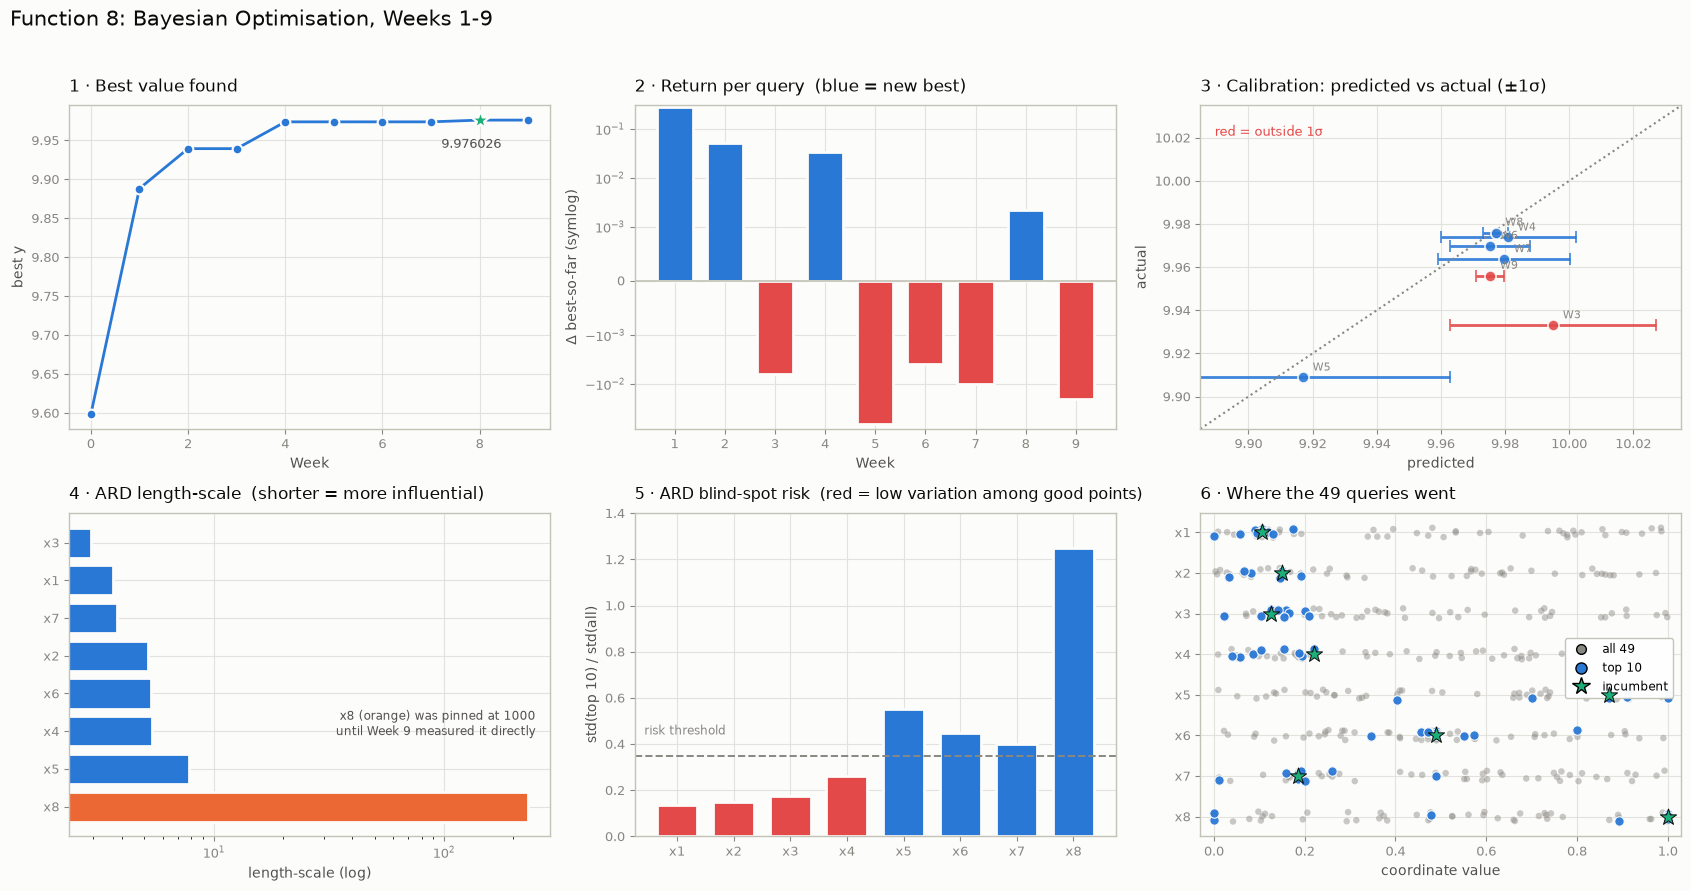

In [178]:
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
INK, INK2, MUTED        = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"

weeks  = list(range(1, 10))
y_obs  = [9.888207, 9.939383, 9.933047, 9.973776, 9.908828,
          9.969918, 9.963750, 9.976026, 9.956026]
best   = np.maximum.accumulate([Y0.max()] + y_obs)
deltas = [best[i+1] - best[i] if y_obs[i] > best[i] else y_obs[i] - best[i+1]
          for i in range(9)]
deltas = [0.289725, 0.051175, -0.006335, 0.034393, -0.064948,
          -0.003858, -0.010026, 0.002250, -0.020000]

calib = [(3, 9.99500, 0.03200, 9.933047), (4, 9.98100, 0.02100, 9.973776),
         (5, 9.91700, 0.04600, 9.908828), (6, 9.97540, 0.01250, 9.969918),
         (7, 9.97975, 0.02062, 9.963750), (8, 9.97705, 0.00378, 9.976026),
         (9, 9.97540, 0.00431, 9.956026)]

fig, axes = plt.subplots(2, 3, figsize = (17, 9), facecolor = SURFACE)
for ax in axes.ravel():
    ax.set_facecolor(SURFACE)
    ax.grid(True, color = GRID, lw = 0.8, alpha = 0.9)
    ax.set_axisbelow(True)
    for sp in ax.spines.values():
        sp.set_color(BASELINE); sp.set_linewidth(1.0)
    ax.tick_params(colors = MUTED, labelsize = 9)

# --- 1. convergence -------------------------------------------------
ax = axes[0, 0]
ax.plot(range(0, 10), best, '-o', color = BLUE, lw = 2, ms = 7,
        markeredgecolor = SURFACE, markeredgewidth = 1.5)
ax.scatter([8], [best[8]], s = 190, marker = '*', color = AQUA,
           edgecolor = SURFACE, linewidth = 1.5, zorder = 6)
ax.annotate(f"{best[8]:.6f}", (8, best[8]), textcoords = "offset points",
            xytext = (-6, -20), fontsize = 9, color = INK2, ha = "center")
ax.set_title("1 · Best value found", fontsize = 12, color = INK, loc = "left", pad = 10)
ax.set_xlabel("Week", color = INK2, fontsize = 10)
ax.set_ylabel("best y", color = INK2, fontsize = 10)

# --- 2. return per query (signed -> diverging) -----------------------
ax = axes[0, 1]
ax.bar(weeks, deltas, color = [BLUE if d > 0 else RED for d in deltas],
       edgecolor = SURFACE, linewidth = 2, width = 0.72)
ax.axhline(0, color = BASELINE, lw = 1.2)
ax.set_yscale("symlog", linthresh = 1e-3)
ax.set_title("2 · Return per query  (blue = new best)", fontsize = 12, color = INK, loc = "left", pad = 10)
ax.set_xlabel("Week", color = INK2, fontsize = 10)
ax.set_ylabel("Δ best-so-far (symlog)", color = INK2, fontsize = 10)
ax.set_xticks(weeks)

# --- 3. calibration -------------------------------------------------
ax = axes[0, 2]
for wk, m_, s_, a_ in calib:
    z = (a_ - m_) / s_
    col = RED if abs(z) > 1 else BLUE
    ax.errorbar(m_, a_, xerr = s_, fmt = 'o', color = col, ms = 8,
                ecolor = col, elinewidth = 2, capsize = 4, alpha = 0.9,
                markeredgecolor = SURFACE, markeredgewidth = 1.2)
    ax.annotate(f"W{wk}", (m_, a_), textcoords = "offset points",
                xytext = (7, 5), fontsize = 8, color = MUTED)
lims = [9.885, 10.035]
ax.plot(lims, lims, ':', color = MUTED, lw = 1.5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title("3 · Calibration: predicted vs actual (±1σ)", fontsize = 12, color = INK, loc = "left", pad = 10)
ax.set_xlabel("predicted", color = INK2, fontsize = 10)
ax.set_ylabel("actual", color = INK2, fontsize = 10)
ax.text(0.03, 0.94, "red = outside 1σ", transform = ax.transAxes,
        fontsize = 9, color = RED, va = "top")

# --- 4. ARD relevance ------------------------------------------------
ax = axes[1, 0]
order = np.argsort(ls_w10)
ax.barh([f"x{i+1}" for i in order], [ls_w10[i] for i in order],
        color = [ORANGE if i == 7 else BLUE for i in order],
        edgecolor = SURFACE, linewidth = 2)
ax.set_xscale("log")
ax.invert_yaxis()
ax.set_title("4 · ARD length-scale  (shorter = more influential)", fontsize = 12, color = INK, loc = "left", pad = 10)
ax.set_xlabel("length-scale (log)", color = INK2, fontsize = 10)
ax.text(0.97, 0.30, "x8 (orange) was pinned at 1000\nuntil Week 9 measured it directly",
        transform = ax.transAxes, fontsize = 8.5, color = INK2,
        ha = "right", va = "bottom")

# --- 5. blind-spot risk ----------------------------------------------
ax = axes[1, 1]
ratios = [blind[d] for d in range(8)]
ax.bar([f"x{d+1}" for d in range(8)], ratios,
       color = [RED if r < 0.35 else BLUE for r in ratios],
       edgecolor = SURFACE, linewidth = 2, width = 0.72)
ax.axhline(0.35, color = MUTED, ls = '--', lw = 1.4)
ax.text(0.02, 0.35 / max(ratios) + 0.035, "risk threshold", transform = ax.transAxes,
        fontsize = 8.5, color = MUTED, ha = "left")
ax.set_ylim(0, max(ratios) * 1.12)
ax.set_title("5 · ARD blind-spot risk  (red = low variation among good points)",
             fontsize = 11.5, color = INK, loc = "left", pad = 10)
ax.set_ylabel("std(top 10) / std(all)", color = INK2, fontsize = 10)

# --- 6. sampling coverage --------------------------------------------
ax = axes[1, 2]
for d in range(8):
    ax.scatter(X[:, d], np.full(len(X), d) + np.random.uniform(-0.13, 0.13, len(X)),
               s = 22, color = MUTED, alpha = 0.45, edgecolor = "none")
    ax.scatter(X[top10, d], np.full(10, d) + np.random.uniform(-0.13, 0.13, 10),
               s = 46, color = BLUE, alpha = 0.95, edgecolor = SURFACE, linewidth = 0.8)
    ax.scatter([incumbent10[d]], [d], s = 150, marker = '*', color = AQUA,
               edgecolor = INK, linewidth = 0.7, zorder = 6)
ax.set_yticks(range(8)); ax.set_yticklabels([f"x{d+1}" for d in range(8)])
ax.invert_yaxis()
ax.set_xlim(-0.03, 1.03)
ax.set_title("6 · Where the 49 queries went", fontsize = 12, color = INK, loc = "left", pad = 10)
ax.set_xlabel("coordinate value", color = INK2, fontsize = 10)
from matplotlib.lines import Line2D
ax.legend(handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=MUTED, markersize=7, label='all 49'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=BLUE, markersize=8, label='top 10'),
    Line2D([0], [0], marker='*', color='none', markerfacecolor=AQUA, markersize=13, label='incumbent')],
    fontsize = 8.5, loc = "center right", bbox_to_anchor = (0.995, 0.52),
    framealpha = 0.96, edgecolor = BASELINE)

fig.suptitle("Function 8: Bayesian Optimisation, Weeks 1-9", fontsize = 15,
             color = INK, x = 0.008, ha = "left", y = 0.985)
plt.tight_layout(rect = [0, 0, 1, 0.965])
plt.show()

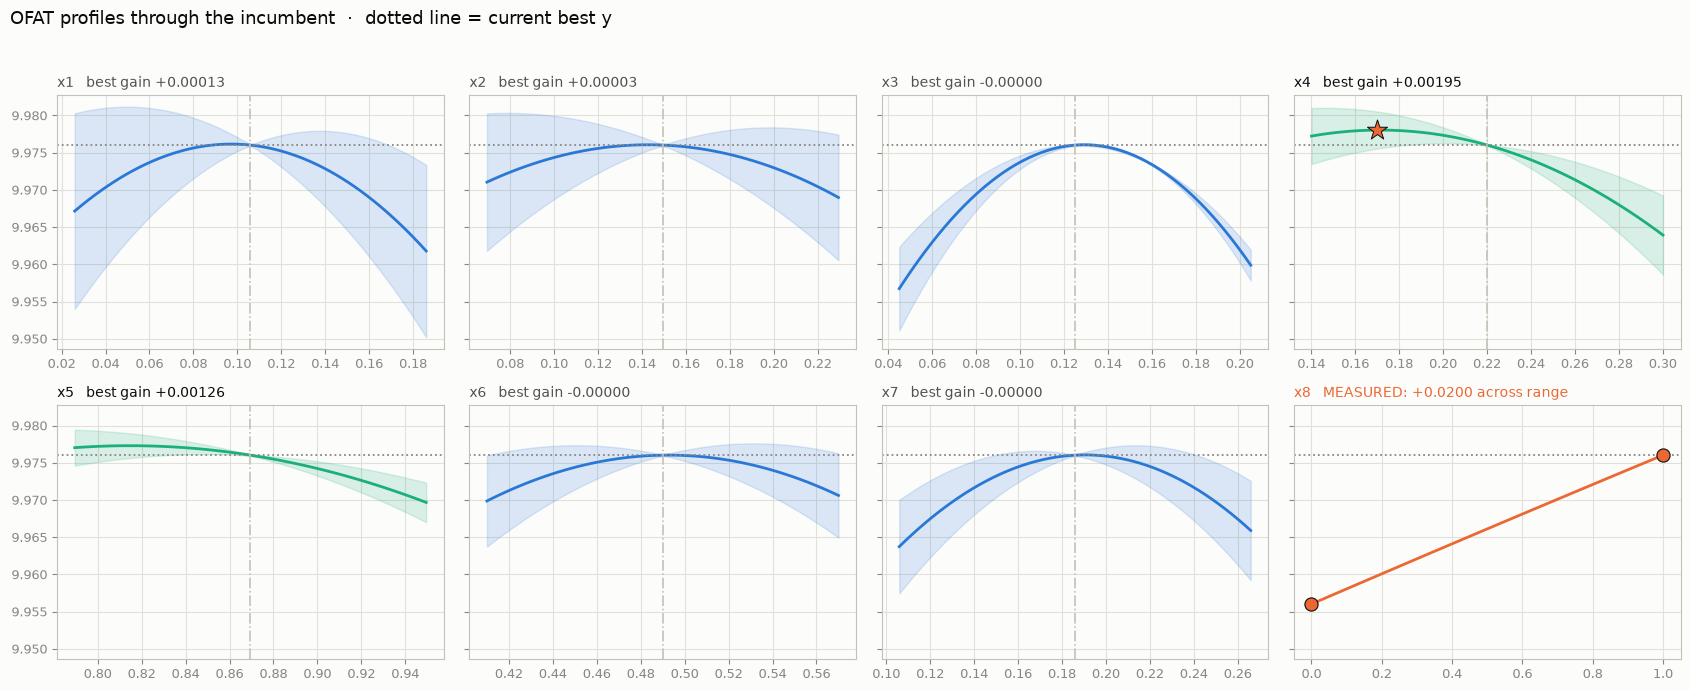

x4 is the only coordinate offering a gain above 0.001; the star marks the Week 10 query.
x8 is shown with its two measured endpoints - the only dimension whose effect is known
from direct observation rather than inferred by the model.


In [174]:
# OFAT profile bundle - where every coordinate stands

fig, axes = plt.subplots(2, 4, figsize = (17, 7), sharey = True, facecolor = SURFACE)
grid = np.linspace(-0.08, 0.08, 55)

for d in range(8):
    ax = axes[d // 4, d % 4]
    ax.set_facecolor(SURFACE)
    ax.grid(True, color = GRID, lw = 0.8); ax.set_axisbelow(True)
    for sp in ax.spines.values(): sp.set_color(BASELINE)
    ax.tick_params(colors = MUTED, labelsize = 9)

    if d < 7:
        xs = incumbent10[d] + grid
        mus, sds = [], []
        for off in grid:
            p = incumbent10.copy(); p[d] = np.clip(p[d] + off, 0, 0.999999)
            m, s = gp_w10.predict(p.reshape(1, -1), return_std = True)
            mus.append(m[0]); sds.append(s[0])
        mus, sds = np.array(mus), np.array(sds)
        gain = gain10[d]
        col = AQUA if gain > 0.001 else BLUE
        ax.plot(xs, mus, color = col, lw = 2)
        ax.fill_between(xs, mus - sds, mus + sds, color = col, alpha = 0.16)
        ax.axhline(y_best, color = MUTED, ls = ':', lw = 1.3)
        ax.axvline(incumbent10[d], color = BASELINE, ls = '-.', lw = 1.2)
        if d == 3:
            ax.scatter([X_next[3]], [best_m], marker = '*', s = 230, color = ORANGE,
                       edgecolor = INK, linewidth = 0.7, zorder = 6)
        ax.set_title(f"x{d+1}   best gain {gain:+.5f}", fontsize = 10,
                     color = INK if gain > 0.001 else INK2, loc = "left")
    else:
        xs = np.linspace(0, 0.999999, 55)
        mus = [gp_w10.predict(np.append(incumbent10[:7], v).reshape(1, -1))[0] for v in xs]
        ax.plot(xs, mus, color = ORANGE, lw = 2)
        ax.scatter([0.999999, 0.0], [Y_w8_new_point[0], Y_w9_new_point[0]],
                   s = 90, color = ORANGE, edgecolor = INK, linewidth = 0.8, zorder = 6)
        ax.axhline(y_best, color = MUTED, ls = ':', lw = 1.3)
        ax.set_title("x8   MEASURED: +0.0200 across range", fontsize = 10, color = ORANGE, loc = "left")

fig.suptitle("OFAT profiles through the incumbent  ·  dotted line = current best y",
             fontsize = 13, color = INK, x = 0.008, ha = "left", y = 0.98)
plt.tight_layout(rect = [0, 0, 1, 0.955])
plt.show()

print("x4 is the only coordinate offering a gain above 0.001; the star marks the Week 10 query.")
print("x8 is shown with its two measured endpoints - the only dimension whose effect is known")
print("from direct observation rather than inferred by the model.")